In [ ]:
!pip install xlsxwriter
import numpy as np
import pandas as pd

input_file = "/content/raw_modified(aug-dec).xlsx"
output_file = "imputed(aug-dec).xlsx"

lag = 24
days = 7
xls = pd.ExcelFile(input_file)

writer = pd.ExcelWriter(output_file, engine='xlsxwriter')

for sheet in xls.sheet_names:

    df = pd.read_excel(input_file, sheet_name=sheet)

    values = df["PM2.5 (µg/m³)"].astype(float).values
    imputed = values.copy()
    n = len(imputed)

    for i in range(n):

        if np.isnan(imputed[i]):

            neighbours = []

            for d in range(1, days+1):

                past = i - d*lag
                future = i + d*lag

                if past >= 0 and not np.isnan(imputed[past]):
                    neighbours.append(imputed[past])

                if future < n and not np.isnan(imputed[future]):
                    neighbours.append(imputed[future])
            if neighbours:
                imputed[i] = np.mean(neighbours)
            else:
                for d in range(days, 0, -1):

                    idx = i - d*lag

                    if idx >= 0 and np.isnan(imputed[idx]):

                        temp = []

                        for k in range(1, days+1):

                            past = idx - k*lag
                            future = idx + k*lag

                            if past >= 0 and not np.isnan(imputed[past]):
                                temp.append(imputed[past])

                            if future < n and not np.isnan(imputed[future]):
                                temp.append(imputed[future])

                        if temp:
                            imputed[idx] = np.mean(temp)

                neighbours = []

                for d in range(1, days+1):

                    past = i - d*lag
                    future = i + d*lag

                    if past >= 0 and not np.isnan(imputed[past]):
                        neighbours.append(imputed[past])

                    if future < n and not np.isnan(imputed[future]):
                        neighbours.append(imputed[future])

                if neighbours:
                    imputed[i] = np.mean(neighbours)

    df["PM2.5 (µg/m³)"] = imputed
    df.to_excel(writer, sheet_name=sheet, index=False)

writer.close()

print("Imputed file saved as:", output_file)

In [ ]:
import pandas as pd

input_file = "/content/imputed(aug-dec).xlsx"
output_file = "rearranged(aug-dec)_dmd.xlsx"

xls = pd.ExcelFile(input_file)
sheet_names = xls.sheet_names

station_data = []

for sheet in sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet)
    timestamp_col = df.columns[0]
    pm25_col = df.columns[1]

    pm25_values = df[pm25_col].values
    station_data.append(pm25_values)

first_df = pd.read_excel(xls, sheet_name=sheet_names[0])
timestamps = first_df.iloc[:, 0].values

final_df = pd.DataFrame(station_data,index=sheet_names,columns=timestamps)

final_df.to_excel(output_file)

print("Rearranged file saved as:", output_file)

STL decomposition


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL

file_path = "/content/rearranged(jan-june)_dmd.xlsx"
df = pd.read_excel(file_path)

stations = df.iloc[:, 0]

data = df.iloc[:, 1:]

data.columns = pd.to_datetime(data.columns)

periods = (24)

mstl_results = {}

for i, station in enumerate(stations):

    ts = pd.Series(
        data.iloc[i].values.astype(float),
        index=data.columns,
        name=station
    )

    mstl = MSTL(ts,periods=periods)

    result = mstl.fit()


    if isinstance(result.seasonal, pd.DataFrame):
        seasonal_total = result.seasonal.sum(axis=1)
    else:
        seasonal_total = result.seasonal

    mstl_results[station] = {
        "original": ts,
        "trend": result.trend,
        "seasonal": seasonal_total,
        "seasonal_components": result.seasonal,
        "residual": result.resid,
        "detrended": ts - result.trend
    }

print("MSTL decomposition completed for all stations.")

MSTL decomposition completed for all stations.


In [ ]:
import pandas as pd
import numpy as np


trend_seasonal_matrix = np.vstack([
    (mstl_results[station]["trend"] +
     mstl_results[station]["seasonal"]).values
    for station in stations
])

trend_seasonal_df = pd.DataFrame(
    trend_seasonal_matrix,
    columns=data.columns
)


trend_seasonal_df.insert(0, df.columns[0], stations.values)

output_file = "trend_plus_seasonal_MSTL(jan-june).xlsx"
trend_seasonal_df.to_excel(output_file, index=False)

print(f"Saved to {output_file}")

Saved to trend_plus_seasonal_MSTL(jan-june).xlsx


In [ ]:
!pip install git+https://github.com/PyDMD/PyDMD.git

  Cloning https://github.com/PyDMD/PyDMD.git to /tmp/pip-req-build-zblp_kyh
  Running command git clone --filter=blob:none --quiet https://github.com/PyDMD/PyDMD.git /tmp/pip-req-build-zblp_kyh
  Resolved https://github.com/PyDMD/PyDMD.git to commit 3e3f7f91125b02688328eb312f7576630c530d15
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00
  Created wheel for PyDMD: filename=pydmd-2025.8.1.post45+git.3e3f7f91-py3-none-any.whl size=154669 sha256=07342f0604de90d84fe696db2c548d724ea1d343a573fe495a4b5c06ee148e56
  Stored in directory: /tmp/pip-ephem-wheel-cache-4g4fk21o/wheels/a8/8e/94/488238a5f4632553c75f84fe247792f18dc619e7e289674ec2
Successfully built PyDMD


Standard DMD

In [ ]:
import numpy as np
import pandas as pd
from pydmd import DMD

window_size = 120
step_size = 1
forecast_horizon = 6
rank = 14

file_path = "/content/trend_plus_seasonal_MSTL(jan-june).xlsx"

df = pd.read_excel(file_path, index_col=0)

X = df.values
stations = df.index

n_stations, n_time = X.shape

rec_nrmse_range = []
rec_rmse = []
rec_mape = []

for_nrmse_range = []
for_rmse = []
for_mape = []

window_labels = []

def nrmse_range(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse / (np.max(y_true) - np.min(y_true))

def rmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse

def mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / (y_true)))

for start in range(0, n_time - window_size - forecast_horizon + 1, step_size):

    end = start + window_size

    X_train = X[:, start:end]


    window_mean = np.mean(X_train, axis=1, keepdims=True)
    X_window_demeaned = X_train - window_mean

    # -----------------
    # DMD fit
    # -----------------
    dmd = DMD(svd_rank=rank)
    dmd.fit(X_window_demeaned)

    eig = dmd.eigs
    phi = dmd.modes
    b = np.linalg.pinv(phi) @ X_window_demeaned[:, -1]

    # -----------------
    # reconstruction
    # -----------------
    X_rec = dmd.reconstructed_data.real
    X_rec = np.maximum(X_rec + window_mean, 0)

    # -----------------
    # forecast
    # -----------------
    X_fore = np.zeros((n_stations, forecast_horizon))

    for k in range(1, forecast_horizon + 1):

        Lambda_k = np.diag(eig **k)

        x_k = phi @ Lambda_k @ b

        X_fore[:, k-1] = np.maximum(np.real(x_k) + window_mean[:, 0],0)


    X_true_rec = X[:, start:end]
    X_true_fore = X[:, end:end+forecast_horizon]


    rec_r, rec_s, rec_m = [], [], []
    for_r, for_s, for_m = [], [], []

    for s in range(n_stations):

        # reconstruction
        rec_r.append(nrmse_range(X_true_rec[s], X_rec[s]))
        rec_s.append(rmse(X_true_rec[s], X_rec[s]))
        rec_m.append(mape(X_true_rec[s], X_rec[s]))

        # forecast
        for_r.append(nrmse_range(X_true_fore[s], X_fore[s]))
        for_s.append(rmse(X_true_fore[s], X_fore[s]))
        for_m.append(mape(X_true_fore[s], X_fore[s]))

    rec_nrmse_range.append(rec_r)
    rec_rmse.append(rec_s)
    rec_mape.append(rec_m)

    for_nrmse_range.append(for_r)
    for_rmse.append(for_s)
    for_mape.append(for_m)

    window_labels.append(start)

print("Total windows:", len(window_labels))

# -----------------------------
# DATAFRAMES
# -----------------------------
rec_nrmse_range_df = pd.DataFrame(rec_nrmse_range,
                                 columns=stations,
                                 index=window_labels)

rec_rmse_df = pd.DataFrame(rec_rmse,
                               columns=stations,
                               index=window_labels)

rec_mape_df = pd.DataFrame(rec_mape,
                           columns=stations,
                           index=window_labels)

for_nrmse_range_df = pd.DataFrame(for_nrmse_range,
                                 columns=stations,
                                 index=window_labels)

for_rmse_df = pd.DataFrame(for_rmse,
                               columns=stations,
                               index=window_labels)

for_mape_df = pd.DataFrame(for_mape,
                           columns=stations,
                           index=window_labels)

with pd.ExcelWriter("DMD_error_metrics(jan-june)(r=14).xlsx") as writer:

    rec_nrmse_range_df.to_excel(writer,
                               sheet_name="REC_NRMSE_range")

    rec_rmse_df.to_excel(writer,
                             sheet_name="REC_RMSE")

    rec_mape_df.to_excel(writer,
                         sheet_name="REC_MAPE")

    for_nrmse_range_df.to_excel(writer,
                               sheet_name="FOR_NRMSE_range")

    for_rmse_df.to_excel(writer,
                             sheet_name="FOR_RMSE")

    for_mape_df.to_excel(writer,
                         sheet_name="FOR_MAPE")

print("Excel saved: DMD_error_metrics.xlsx")

Total windows: 4219
Excel saved: DMD_error_metrics.xlsx


Eigenvalues plot of DMD

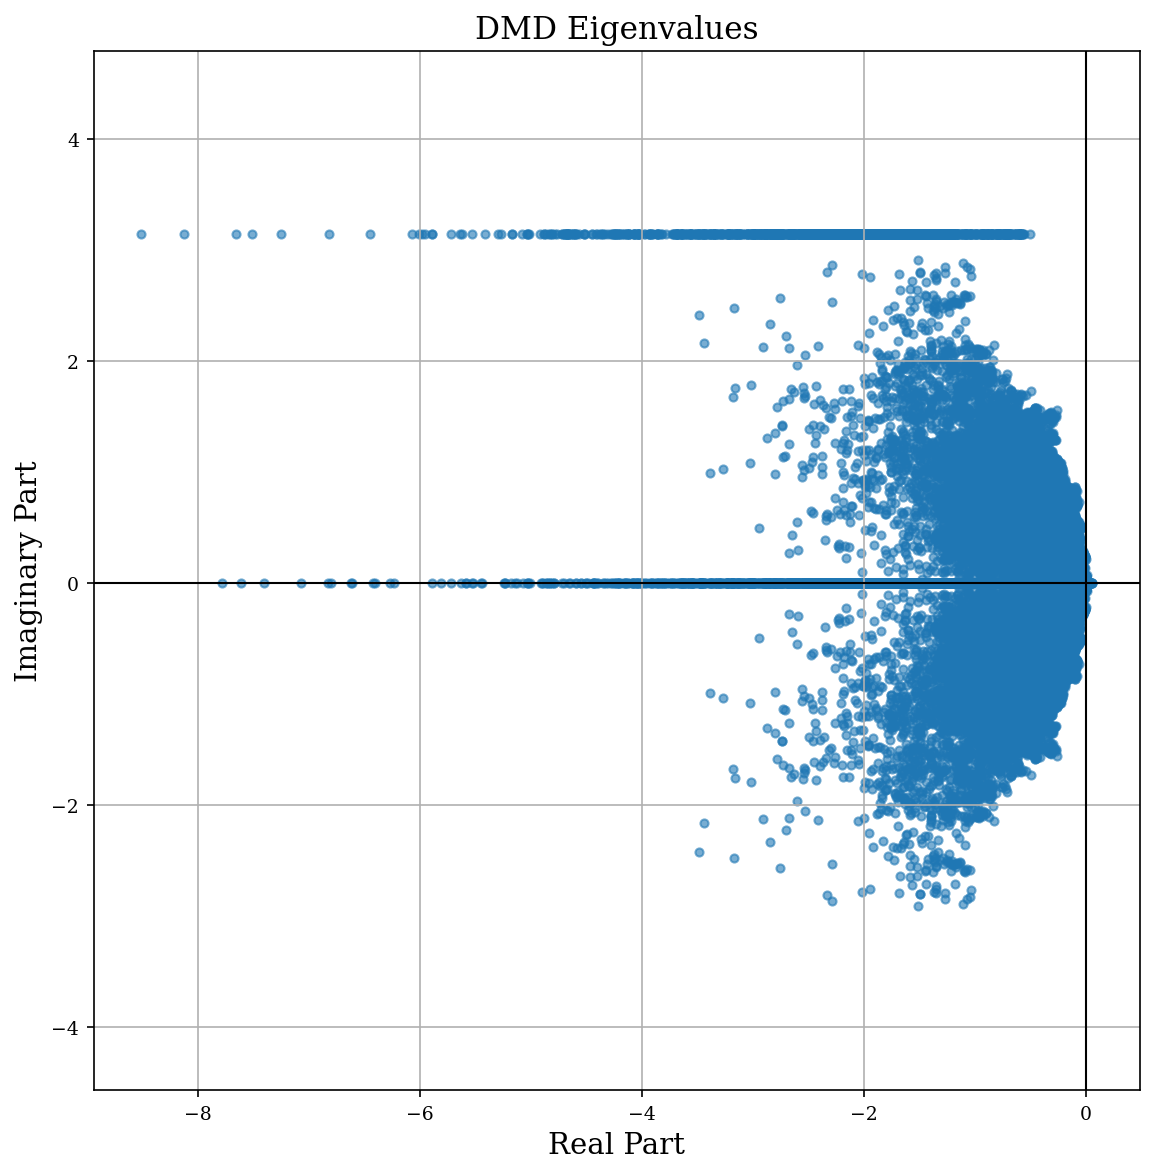

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydmd import DMD

window_size = 96
step_size = 1
forecast_horizon = 6
rank = 14

dt = 1.0

file_path = "/content/trend_plus_seasonal_MSTL(jan-june).xlsx"

df = pd.read_excel(file_path, index_col=0)
X = df.values
n_stations, n_time = X.shape

all_omega = []

# -----------------------------
# SLIDING WINDOW DMD
# -----------------------------
for start in range(0,n_time - window_size - forecast_horizon + 1, step_size):

    end = start + window_size

    X_train = X[:, start:end]
    window_mean = np.mean(X_train, axis=1, keepdims=True)
    X_demeaned = X_train - window_mean

    # DMD
    dmd = DMD(svd_rank=rank)
    dmd.fit(X_demeaned)
    eigs = dmd.eigs
    omega = np.log(eigs) / dt
    all_omega.extend(omega)

all_omega = np.array(all_omega)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(9,9))

plt.scatter(all_omega.real,
            all_omega.imag,
            s=15,
            alpha=0.6)

# axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.xlabel("Real Part",
           fontsize=14)

plt.ylabel("Imaginary Part",
           fontsize=14)

plt.title(f"DMD Eigenvalues",
          fontsize=15)

plt.grid(True)


plt.axis('equal')

# optional limits
# plt.xlim([-1, 1])
# plt.ylim([-10, 10])


plt.savefig("DMD eigenvalues jan-june.png",dpi=300, bbox_inches='tight')

plt.show()

Saved figure to DMD_reconstruction_window_0(jan-june).png


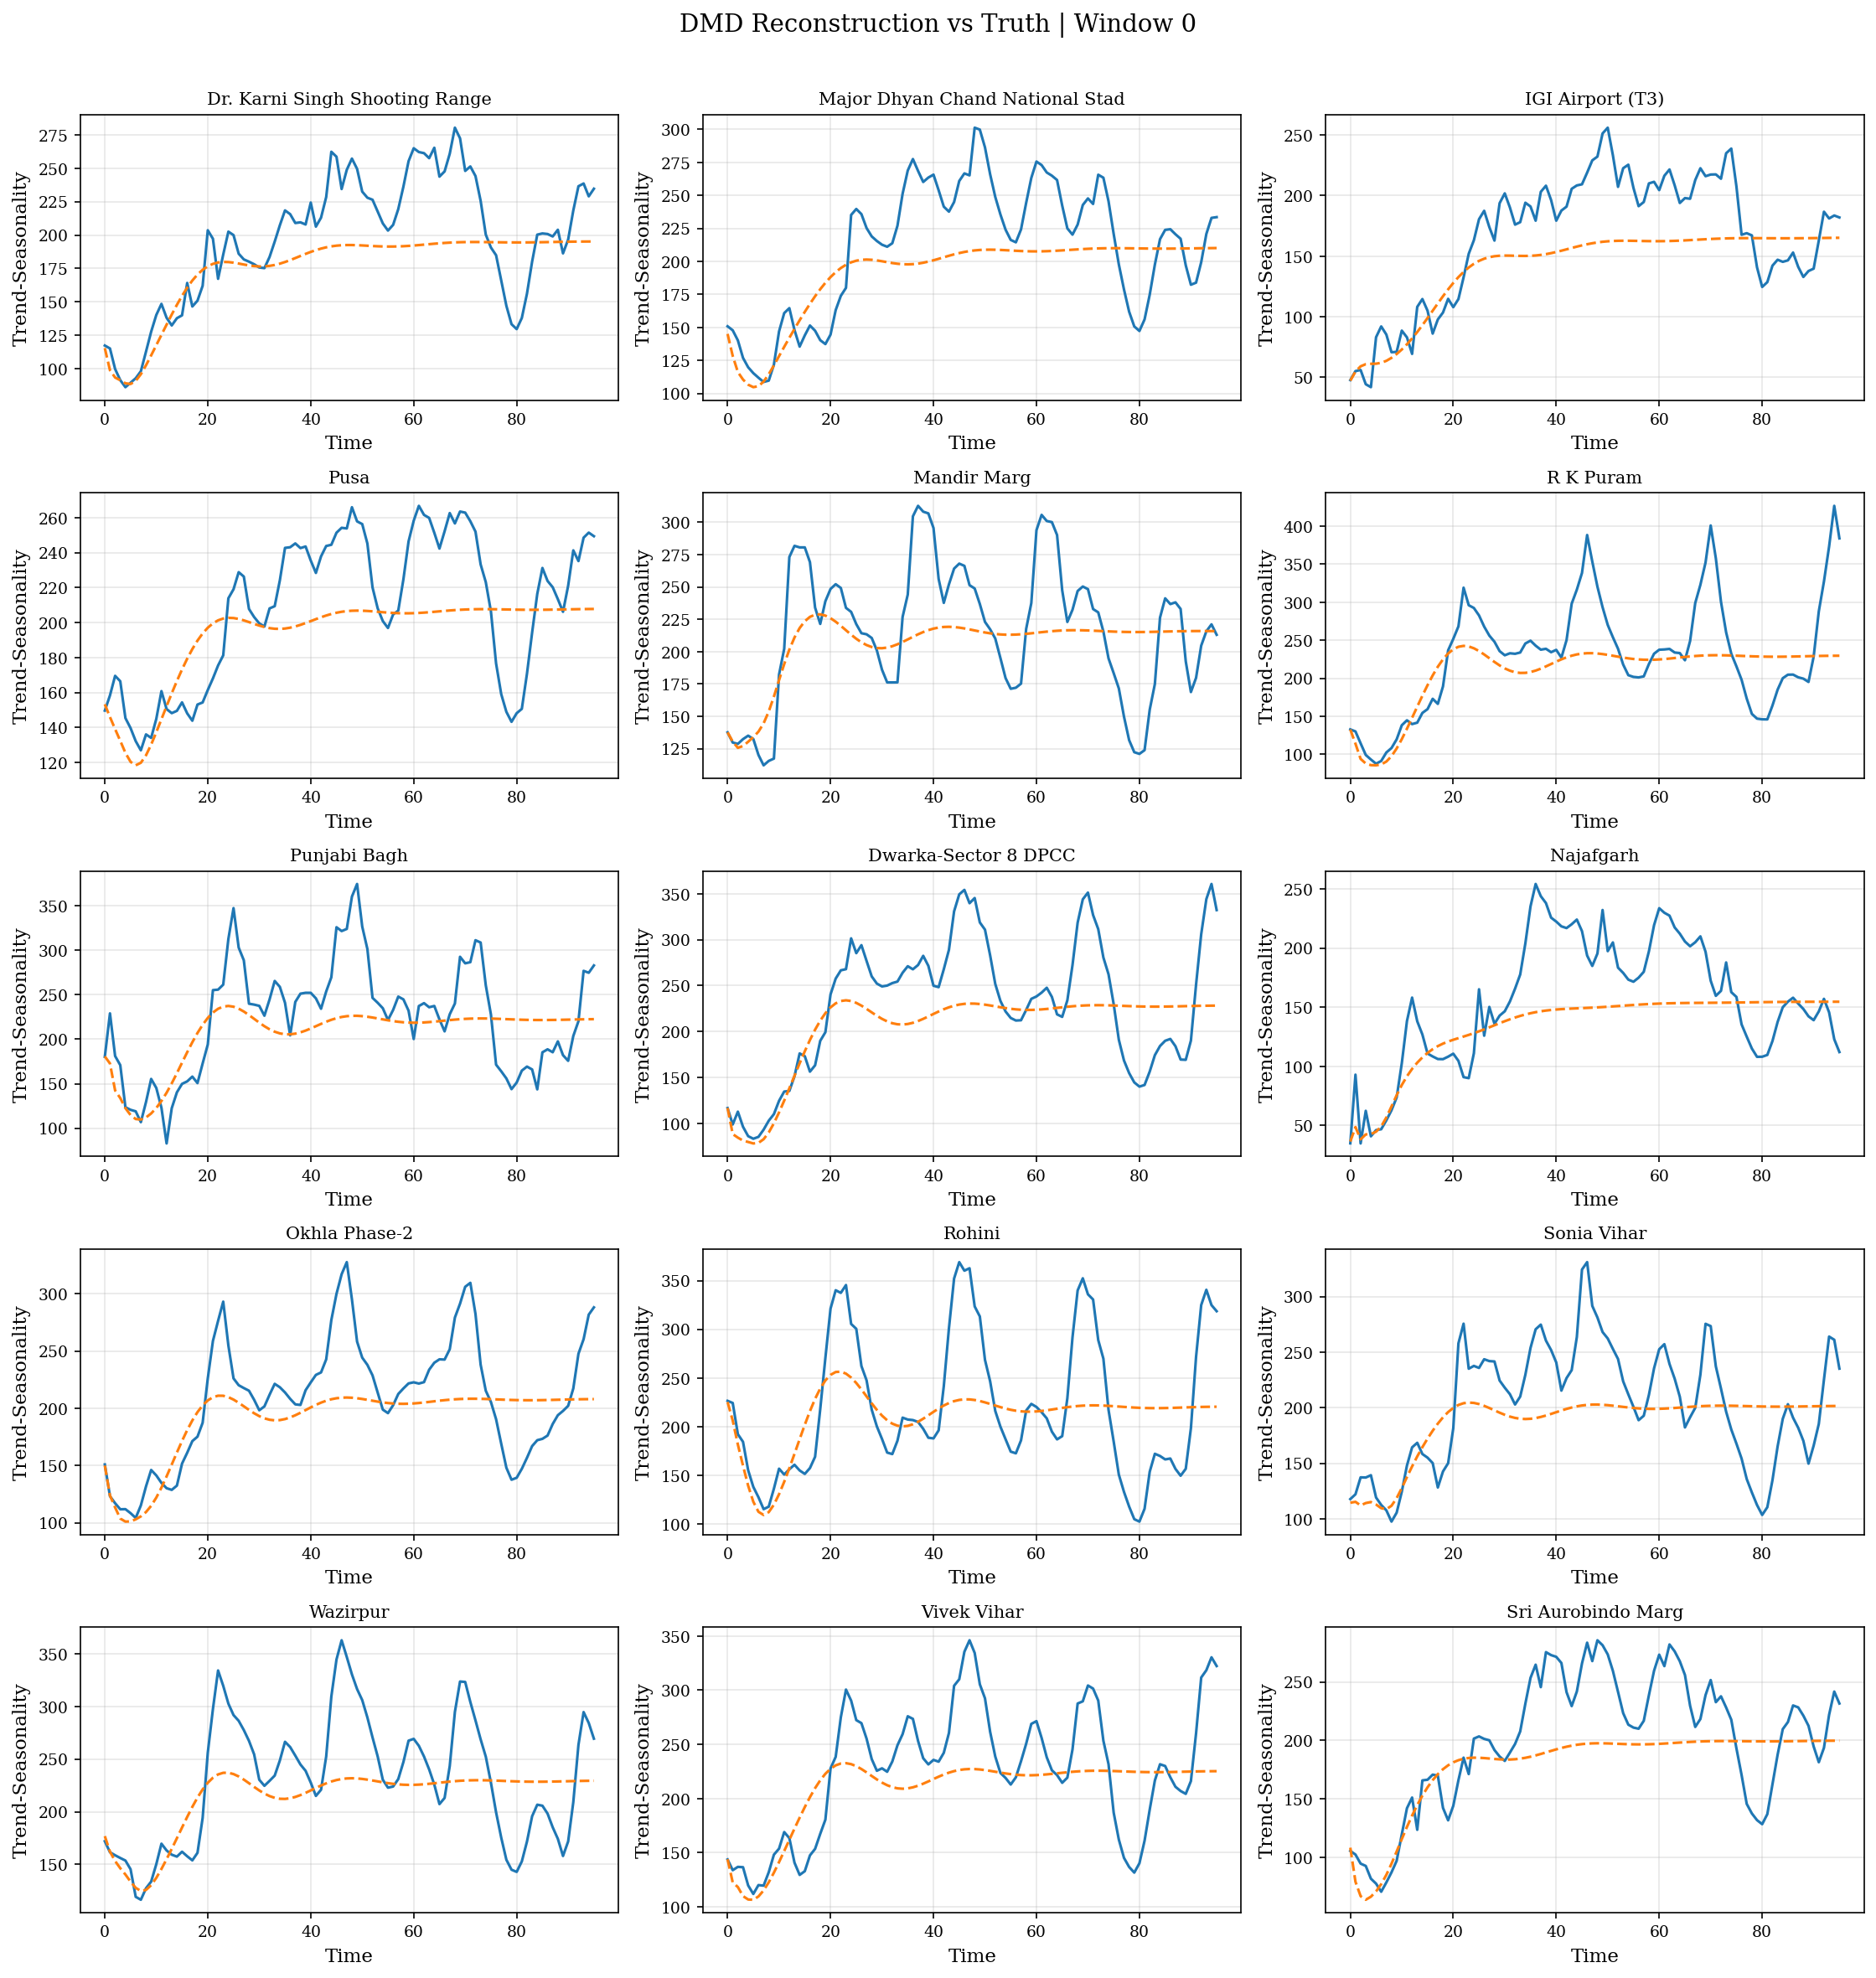

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD
from matplotlib.ticker import MultipleLocator

window_start = 0
end = window_start + window_size

X_train = X[:, window_start:end]
window_mean = np.mean(X_train, axis=1, keepdims=True)
X_window_demeaned = X_train - window_mean

dmd = DMD(svd_rank=rank)
dmd.fit(X_window_demeaned)

X_rec = np.maximum(dmd.reconstructed_data.real + window_mean, 0)

X_true_rec = X[:, window_start:end]

# -----------------------------
# DYNAMIC GRID PLOT
# -----------------------------
n_stations = X.shape[0]
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)  # flatten regardless of shape


for s in range(nrows * ncols):
    ax = axes[s]
    if s < n_stations:
        ax.plot(X_true_rec[s], label="Observed", color="tab:blue", linewidth=1.5)
        ax.plot(X_rec[s], label="Reconstructed", color="tab:orange", linestyle="--", linewidth=1.5)

        clean_title = stations[s].replace("_", " ").replace("Delhi", "").strip()
        clean_title = " ".join(clean_title.split())
        ax.set_title(clean_title, fontsize=10)

        ax.set_xlabel("Time")
        ax.set_ylabel("Trend-Seasonality")

        ax.xaxis.set_major_locator(MultipleLocator(20))
        ax.tick_params(axis='x', labelbottom=True)

        ax.grid(True, alpha=0.3)
        #ax.legend(loc="upper right", fontsize=8)
    else:
        ax.axis("off")

fig.suptitle(f"DMD Reconstruction vs Truth | Window {window_start}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])

save_path = f"DMD_reconstruction_window_{window_start}(jan-june).png"
fig.savefig(save_path, dpi=600, bbox_inches="tight")
print(f"Saved figure to {save_path}")

plt.show()

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pydmd import DMD

# -----------------------------------
# PARAMETERS
# -----------------------------------
window_size = 120
step_size = 1
forecast_horizon = 6
rank = 14

# -----------------------------------
# CHOOSE WINDOW RANGE TO PLOT
# -----------------------------------
window_start_idx = 2501     # First window to plot
window_end_idx = 4219      # Last window to plot (inclusive)

# -----------------------------------
# DATA INFORMATION
# -----------------------------------
n_stations, n_time = X.shape

# Total windows (same as forecasting code)
total_windows = len(range(0,n_time - window_size - forecast_horizon + 1,step_size))

print(f"Total available windows = {total_windows}")

# Maximum valid starting index
max_window_start = n_time - window_size - forecast_horizon

# Ensure requested window range is valid
window_start_idx = max(0, window_start_idx)
window_end_idx = min(window_end_idx, max_window_start)

print(f"Processing windows {window_start_idx} to {window_end_idx}")

# -----------------------------------
# CREATE OUTPUT FOLDER
# -----------------------------------
output_folder = "DMD_Reconstruction_Plots_2501-4219(jan-june)"
os.makedirs(output_folder, exist_ok=True)

# -----------------------------------
# LOOP OVER SELECTED WINDOWS
# -----------------------------------
for window_start in range(window_start_idx,
                          window_end_idx + 1,
                          step_size):

    end = window_start + window_size

    # -----------------------------
    # Training data
    # -----------------------------
    X_train = X[:, window_start:end]

    window_mean = np.mean(X_train, axis=1, keepdims=True)
    X_window_demeaned = X_train - window_mean

    # -----------------------------
    # DMD
    # -----------------------------
    dmd = DMD(svd_rank=rank)
    dmd.fit(X_window_demeaned)

    X_rec = np.maximum(
        dmd.reconstructed_data.real + window_mean,
        0
    )

    X_true_rec = X[:, window_start:end]

    # -----------------------------
    # Figure layout
    # -----------------------------
    ncols = 3
    nrows = int(np.ceil(n_stations / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True
    )

    axes = np.array(axes).reshape(-1)

    for s in range(nrows * ncols):

        ax = axes[s]

        if s < n_stations:

            ax.plot(
                X_true_rec[s],
                color="tab:blue",
                linewidth=1.5
            )

            ax.plot(
                X_rec[s],
                color="tab:orange",
                linestyle="--",
                linewidth=1.5
            )

            clean_title = (
                stations[s]
                .replace("_", " ")
                .replace("Delhi", "")
                .strip()
            )
            clean_title = " ".join(clean_title.split())

            ax.set_title(clean_title, fontsize=10)
            ax.set_xlabel("Time")
            ax.set_ylabel("Trend-Seasonality")

            ax.xaxis.set_major_locator(MultipleLocator(20))
            ax.tick_params(axis='x', labelbottom=True)

            ax.grid(True, alpha=0.3)

        else:
            ax.axis("off")

    fig.suptitle(
        f"DMD Reconstruction | Window {window_start}",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # -----------------------------
    # Save figure
    # -----------------------------
    filename = os.path.join(
        output_folder,
        f"window_{window_start:04d}.png"
    )

    fig.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"Saved: {filename}")

# -----------------------------------
# CREATE ZIP FILE
# -----------------------------------
zip_filename = "DMD_Reconstruction_Plots_2501-4219(jan-june).zip"

with zipfile.ZipFile(zip_filename,
                     "w",
                     zipfile.ZIP_DEFLATED) as zipf:

    for file in sorted(os.listdir(output_folder)):
        filepath = os.path.join(output_folder, file)
        zipf.write(filepath, arcname=file)

print(f"\nZIP file created successfully: {zip_filename}")

OptDMDs


In [ ]:
import numpy as np
import pandas as pd
from pydmd import BOPDMD

window_size = 96
step_size = 1
forecast_horizon = 6
rank = 14

file_path = "/content/trend_plus_seasonal_MSTL(aug-dec).xlsx"

df = pd.read_excel(file_path, index_col=0)
X = df.values
stations = df.index
n_stations, n_time = X.shape

rec_nrmse_range = []
rec_rmse = []
rec_mape = []

for_nrmse_range = []
for_rmse = []
for_mape = []

eig_smallest = []
eig_largest = []

window_labels = []

def nrmse_range(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse / (np.max(y_true) - np.min(y_true))

def rmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse

def mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / y_true))

# -----------------------------
# SLIDING WINDOW BOPDMD
# -----------------------------
for start in range(0, n_time - window_size - forecast_horizon + 1, step_size):

    end = start + window_size

    X_train = X[:, start:end]
    window_mean = np.mean(X_train, axis=1, keepdims=True)

    X_demeaned = X_train - window_mean
    t_train = np.arange(window_size)

    # -----------------------------
    # FIT BOPDMD
    # -----------------------------
    bopdmd = BOPDMD(
        svd_rank=rank, eig_constraints={"stable"})#,num_trials=25)

    bopdmd.fit(X_demeaned, t_train)

    # -----------------------------
    # RECONSTRUCTION
    # -----------------------------
    X_rec = bopdmd.reconstructed_data.real

    X_rec = X_rec + window_mean

    X_rec = np.maximum(X_rec, 0)

    # -----------------------------
    # FORECAST
    # -----------------------------


    omega = bopdmd.eigs

    # record smallest/largest eigenvalue (by magnitude) for this window
    eig_mags = np.abs(omega)
    eig_smallest.append(eig_mags.min())
    eig_largest.append(eig_mags.max())

    phi = bopdmd.modes


    b = np.linalg.pinv(phi) @ X_demeaned[:, -1]

    X_fore = np.zeros((n_stations, forecast_horizon))

    for k in range(1, forecast_horizon+1):


        time_dynamics = np.exp(omega * k)

        x_k = phi @ (time_dynamics * b)

        X_fore[:, k-1] = np.maximum(np.real(x_k) + window_mean[:,0], 0 )

    # -----------------------------
    # TRUE VALUES
    # -----------------------------
    X_true_rec = X[:, start:end]

    X_true_fore = X[:, end:end+forecast_horizon]

    # -----------------------------
    # METRICS
    # -----------------------------
    rec_r, rec_s, rec_m = [], [], []

    for_r, for_s, for_m = [], [], []

    for s in range(n_stations):

        rec_r.append(
            nrmse_range(
                X_true_rec[s],
                X_rec[s]
            )
        )

        rec_s.append(
            rmse(
                X_true_rec[s],
                X_rec[s]
            )
        )

        rec_m.append(
            mape(
                X_true_rec[s],
                X_rec[s]
            )
        )

        for_r.append(
            nrmse_range(
                X_true_fore[s],
                X_fore[s]
            )
        )

        for_s.append(
            rmse(
                X_true_fore[s],
                X_fore[s]
            )
        )

        for_m.append(
            mape(
                X_true_fore[s],
                X_fore[s]
            )
        )

    rec_nrmse_range.append(rec_r)

    rec_rmse.append(rec_s)

    rec_mape.append(rec_m)

    for_nrmse_range.append(for_r)

    for_rmse.append(for_s)

    for_mape.append(for_m)

    window_labels.append(start)


print("Total windows =", len(window_labels))

# -----------------------------
# SAVE RESULTS
# -----------------------------
with pd.ExcelWriter(
    "OptDMD_error_metrics(stable)_au.xlsx"
) as writer:

    pd.DataFrame(
        rec_nrmse_range,
        columns=stations,
        index=window_labels
    ).to_excel(writer,"REC_NRMSE_range")


    pd.DataFrame(
        rec_rmse,
        columns=stations,
        index=window_labels
    ).to_excel(writer,"REC_RMSE")


    pd.DataFrame(
        rec_mape,
        columns=stations,
        index=window_labels
    ).to_excel(writer,"REC_MAPE")


    pd.DataFrame(
        for_nrmse_range,
        columns=stations,
        index=window_labels
    ).to_excel(writer,"FOR_NRMSE_range")


    pd.DataFrame(
        for_rmse,
        columns=stations,
        index=window_labels
    ).to_excel(writer,"FOR_RMSE")


    pd.DataFrame(
        for_mape,
        columns=stations,
        index=window_labels
    ).to_excel(writer,"FOR_MAPE")


print("Saved: OptDMD_error_metrics(stable)_aug-dec.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/content/trend_plus_seasonal_MSTL(aug-dec).xlsx'

Saved figure to OptDMDs reconstruction_window_0(jan-june).png


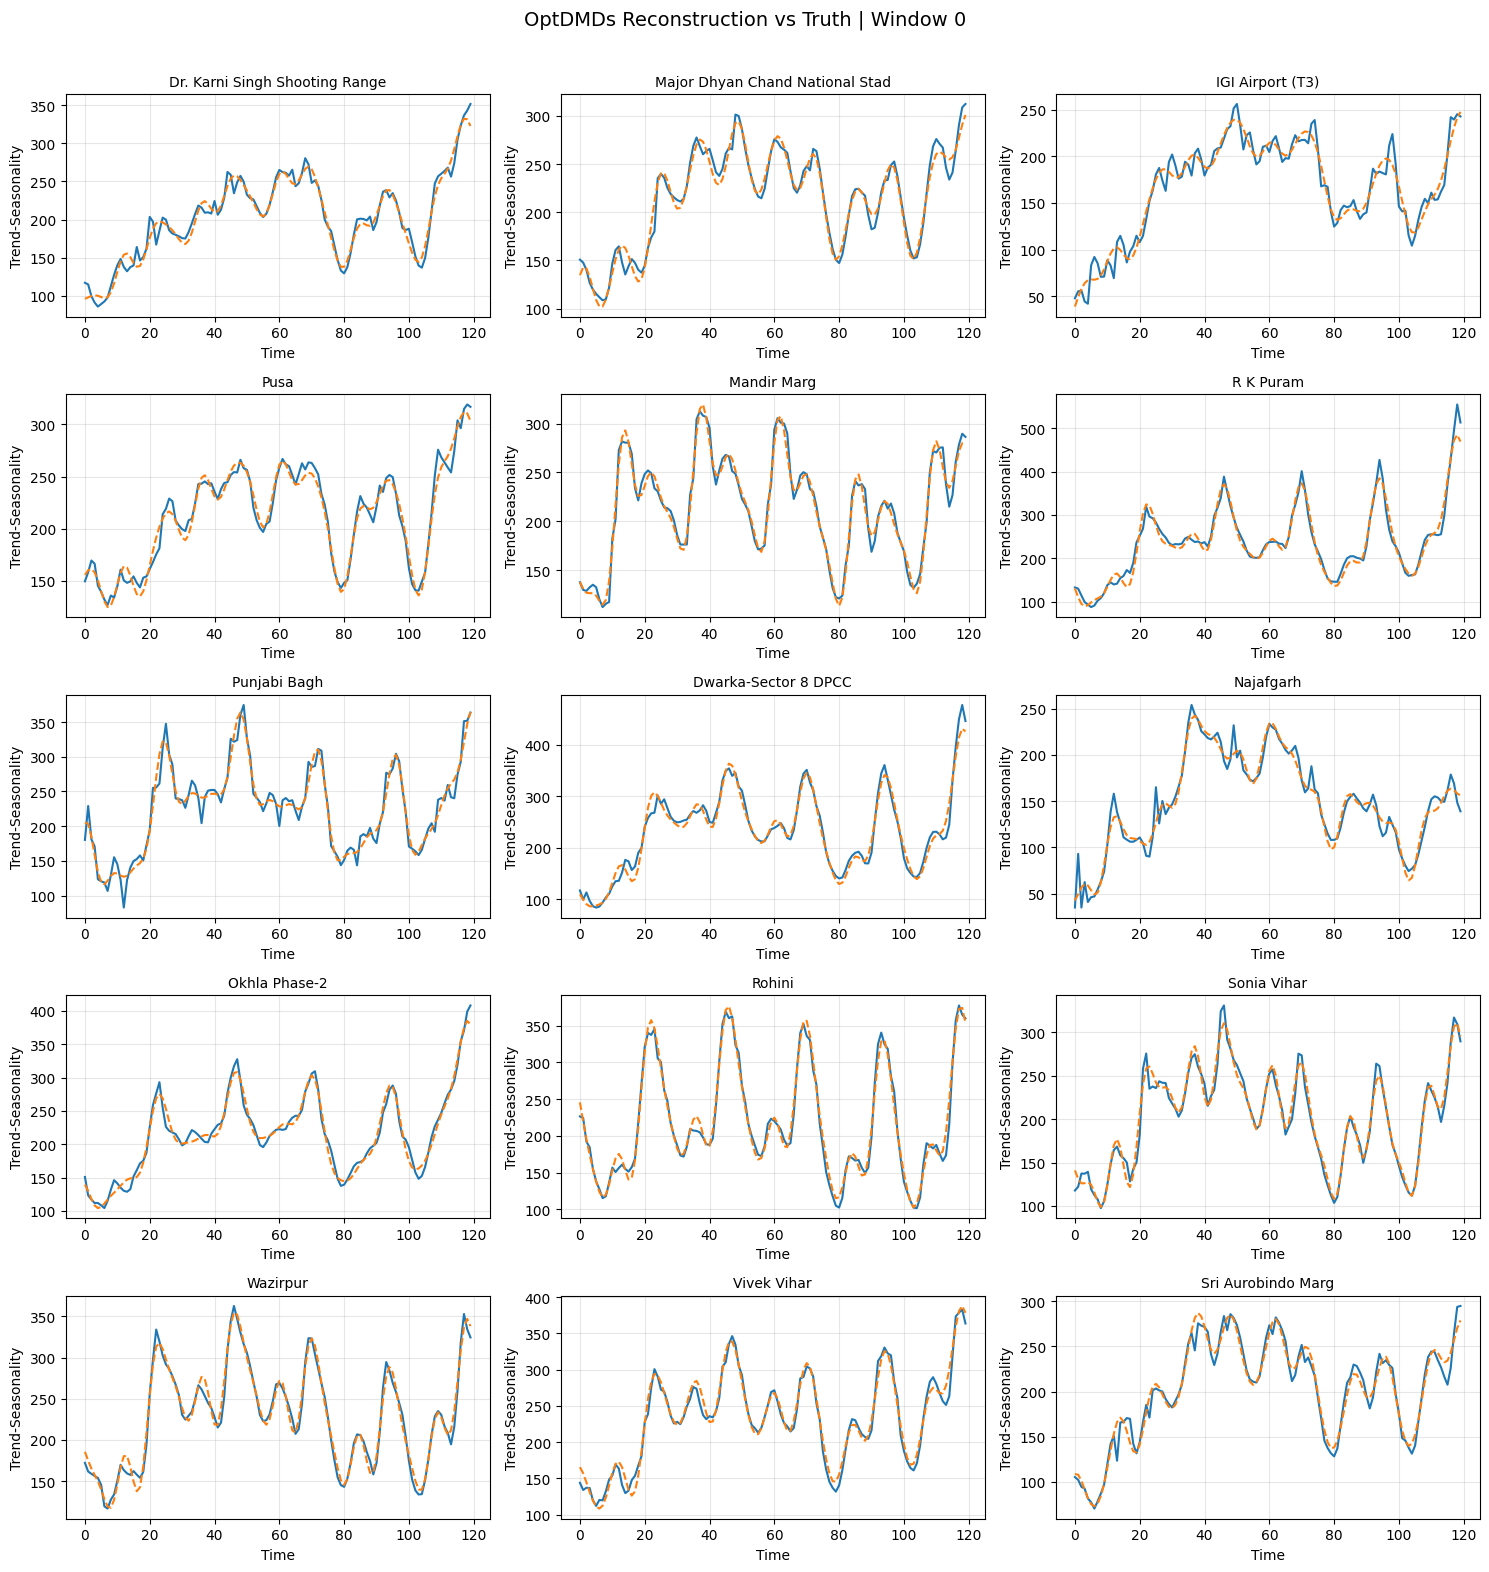

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pydmd import BOPDMD
from matplotlib.ticker import MultipleLocator


start = 0
end = start + window_size

# -----------------------------
# FIT BOPDMD ON THAT WINDOW
# -----------------------------
X_train = X[:, start:end]
window_mean = np.mean(X_train, axis=1, keepdims=True)
X_demeaned = X_train - window_mean
t_train = np.arange(window_size)

bopdmd = BOPDMD(svd_rank=rank, eig_constraints={"stable"})
bopdmd.fit(X_demeaned, t_train)

X_rec = bopdmd.reconstructed_data.real + window_mean
X_rec = np.maximum(X_rec, 0)

X_true_rec = X[:, start:end]

# -----------------------------
# DYNAMIC GRID PLOT
# -----------------------------
n_stations = X.shape[0]
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)  # flatten regardless of shape

for s in range(nrows * ncols):
    ax = axes[s]
    if s < n_stations:
        ax.plot(X_true_rec[s], label="Observed", color="tab:blue", linewidth=1.5)
        ax.plot(X_rec[s], label="Reconstructed", color="tab:orange", linestyle="--", linewidth=1.5)

        clean_title = stations[s].replace("_", " ").replace("Delhi", "").strip()
        clean_title = " ".join(clean_title.split())
        ax.set_title(clean_title, fontsize=10)

        ax.set_xlabel("Time")
        ax.set_ylabel("Trend-Seasonality")

        ax.xaxis.set_major_locator(MultipleLocator(20))
        ax.tick_params(axis='x', labelbottom=True)
        ax.grid(True, alpha=0.3)
        #ax.legend(loc="upper right", fontsize=8)
    else:
        ax.axis("off")

fig.suptitle(f"OptDMDs Reconstruction vs Truth | Window {start}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])

save_path = f"OptDMDs reconstruction_window_{start}(jan-june).png"
fig.savefig(save_path, dpi=600, bbox_inches="tight")
print(f"Saved figure to {save_path}")

plt.show()

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pydmd import BOPDMD

# ============================================================
# PARAMETERS
# ============================================================

# Choose WINDOW NUMBERS (not start indices)
first_window = 1701
last_window = 4219     # Inclusive

# ============================================================
# DATA INFORMATION
# ============================================================

n_stations, n_time = X.shape

# Generate the same windows used in the forecasting code
window_starts = list(
    range(0,n_time - window_size - forecast_horizon + 1,step_size ))

total_windows = len(window_starts)

print(f"Total windows available: {total_windows}")

# Ensure requested window numbers are valid
first_window = max(0, first_window)
last_window = min(last_window, total_windows - 1)

print(f"Processing window numbers {first_window} to {last_window}")

# ============================================================
# OUTPUT FOLDER
# ============================================================

output_folder = "OptDMDs_Reconstruction_Plots_1701-4219(jan-june)"
os.makedirs(output_folder, exist_ok=True)

# ============================================================
# LOOP OVER WINDOW NUMBERS
# ============================================================

for w in range(first_window, last_window + 1):

    try:

        # --------------------------------------------------------
        # Convert window number -> start index
        # --------------------------------------------------------

        start = window_starts[w]
        end = start + window_size

        # --------------------------------------------------------
        # WINDOW
        # --------------------------------------------------------

        X_train = X[:, start:end]

        window_mean = np.mean(X_train, axis=1, keepdims=True)
        X_demeaned = X_train - window_mean

        t_train = np.arange(window_size)

        # --------------------------------------------------------
        # FIT BOPDMD
        # --------------------------------------------------------

        bopdmd = BOPDMD(
            svd_rank=rank,
            eig_constraints={"stable"}
        )

        bopdmd.fit(X_demeaned, t_train)

        # --------------------------------------------------------
        # RECONSTRUCTION
        # --------------------------------------------------------

        X_rec = bopdmd.reconstructed_data.real + window_mean
        X_rec = np.maximum(X_rec, 0)

        X_true_rec = X[:, start:end]

        # --------------------------------------------------------
        # TIME AXIS
        # --------------------------------------------------------

        t_rec = np.arange(start, end)

        # --------------------------------------------------------
        # PLOT
        # --------------------------------------------------------

        ncols = 3
        nrows = int(np.ceil(n_stations / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(5 * ncols, 3.2 * nrows),
            sharex=True
        )

        axes = np.array(axes).reshape(-1)

        for s in range(nrows * ncols):

            ax = axes[s]

            if s < n_stations:

                ax.plot(
                    t_rec,
                    X_true_rec[s],
                    color="tab:blue",
                    linewidth=1.5
                )

                ax.plot(
                    t_rec,
                    X_rec[s],
                    "--",
                    color="tab:orange",
                    linewidth=1.5
                )

                clean_title = (
                    stations[s]
                    .replace("_", " ")
                    .replace("Delhi", "")
                    .strip()
                )
                clean_title = " ".join(clean_title.split())

                ax.set_title(clean_title, fontsize=10)

                ax.set_xlabel("Time Index")
                ax.set_ylabel("Trend-Seasonality")

                ax.xaxis.set_major_locator(MultipleLocator(20))
                ax.tick_params(axis="x", labelbottom=True)

                ax.grid(True, alpha=0.3)

            else:
                ax.axis("off")

        fig.suptitle(
            f"BOPDMD Reconstruction | Window {w} (Start Index = {start})",
            fontsize=14
        )

        plt.tight_layout(rect=[0, 0, 1, 0.97])

        # --------------------------------------------------------
        # SAVE FIGURE
        # --------------------------------------------------------

        filename = os.path.join(
            output_folder,
            f"window_{w:04d}.png"
        )

        fig.savefig(
            filename,
            dpi=150,
            bbox_inches="tight"
        )

        plt.close(fig)

        print(f"Saved window {w} -> {filename}")

    except Exception as e:

        print(f"Window {w} failed: {e}")

# ============================================================
# CREATE ZIP FILE
# ============================================================

zip_filename = "OptDMDs_Reconstruction_Plots_1071-4219(jan-june).zip"

with zipfile.ZipFile(
    zip_filename,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in sorted(os.listdir(output_folder)):
        filepath = os.path.join(output_folder, file)
        zipf.write(filepath, arcname=file)

print(f"\nZIP file created successfully: {zip_filename}")

PARMETER SELECTION


In [ ]:
!pip install PyDMD
import numpy as np
import pandas as pd
from pydmd import HankelDMD
from collections import defaultdict
import openpyxl


filename = "/content/trend_plus_seasonal_MSTL(jan-june).xlsx"

window_sizes      = [120]
forecast_horizons = [6]
delays            = [48]
ranks             = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,
                     56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73]

step_size = 1

output_filename = "/content/rank selection for window(120)_jan-june.xlsx"

df = pd.read_excel(filename)
stations = df.iloc[:, 0].values
data = df.iloc[:, 1:].values.astype(float)

n_stations, total_snapshots = data.shape

results_by_station = {s: [] for s in range(n_stations)}

# ============================================================
# GRID SEARCH
# ============================================================

combo_count = 0
total_combos = len(window_sizes) * len(forecast_horizons) * len(delays) * len(ranks)

for window_size in window_sizes:
    for forecast_horizon in forecast_horizons:
        for d in delays:

            n_windows = (total_snapshots - window_size - forecast_horizon) // step_size + 1

            for r in ranks:

                combo_count += 1
                print(f"[{combo_count}/{total_combos}] window={window_size}, horizon={forecast_horizon}, d={d}, rank={r}")

                ensemble_preds = defaultdict(lambda: defaultdict(list))

                for w in range(n_windows):

                    start = w * step_size
                    end   = start + window_size

                    X_window          = data[:, start:end]
                    window_mean       = np.mean(X_window, axis=1, keepdims=True)
                    X_window_demeaned = X_window - window_mean

                    try:
                        hankel_dmd = HankelDMD(svd_rank=r, d=d)
                        hankel_dmd.fit(X_window_demeaned)
                    except Exception:
                        continue

                    Phi  = hankel_dmd.modes
                    eigs = hankel_dmd.eigs

                    h_0 = hankel_dmd.ho_snapshots[:, -1]
                    b   = np.linalg.pinv(Phi) @ h_0

                    for k in range(1, forecast_horizon + 1):
                        t_idx = end + k - 1
                        if t_idx >= total_snapshots:
                            continue

                        Lambda_k = np.diag(eigs ** k)
                        h_k      = Phi @ Lambda_k @ b
                        x_next   = np.real(h_k[-n_stations:])
                        x_next   = np.maximum(x_next + window_mean[:, 0], 0)

                        for s in range(n_stations):
                            ensemble_preds[t_idx][s].append(x_next[s])

                t_indices = sorted(ensemble_preds.keys())

                for s in range(n_stations):

                    y_true, y_pred = [], []
                    for t in t_indices:
                        if t < total_snapshots and len(ensemble_preds[t][s]) > 0:
                            y_true.append(data[s, t])
                            y_pred.append(np.mean(ensemble_preds[t][s]))

                    if len(y_true) == 0:
                        continue

                    y_true = np.array(y_true)
                    y_pred = np.array(y_pred)

                    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
                    val_range = np.max(y_true) - np.min(y_true)
                    nrmse = rmse / val_range if val_range != 0 else np.nan

                    mask = y_true != 0
                    mape = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
                            if mask.any() else np.nan)

                    results_by_station[s].append({
                        "Window_Size":      window_size,
                        "Forecast_Horizon": forecast_horizon,
                        "Delay":            d,
                        "Rank":             r,
                        "Pred_NRMSE":       round(nrmse, 4) if not np.isnan(nrmse) else nrmse,
                        "Pred_RMSE":        round(rmse, 4),
                        "Pred_MAPE":        round(mape, 2) if not np.isnan(mape) else mape,
                    })

# ============================================================
# WRITE TO EXCEL — ONE SHEET PER STATION
# ============================================================

with pd.ExcelWriter(output_filename, engine="openpyxl") as writer:
    for s in range(n_stations):
        results_df = pd.DataFrame(
            results_by_station[s],
            columns=[
                "Window_Size",
                "Forecast_Horizon",
                "Delay",
                "Rank",
                "Pred_NRMSE",
                "Pred_RMSE",
                "Pred_MAPE"
            ]
        )
        sheet_name = str(stations[s])[:31]  # Excel sheet-name length limit
        results_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Saved: {output_filename}")

[1/73] window=120, horizon=6, d=48, rank=1
[2/73] window=120, horizon=6, d=48, rank=2
[3/73] window=120, horizon=6, d=48, rank=3
[4/73] window=120, horizon=6, d=48, rank=4
[5/73] window=120, horizon=6, d=48, rank=5
[6/73] window=120, horizon=6, d=48, rank=6
[7/73] window=120, horizon=6, d=48, rank=7
[8/73] window=120, horizon=6, d=48, rank=8
[9/73] window=120, horizon=6, d=48, rank=9
[10/73] window=120, horizon=6, d=48, rank=10
[11/73] window=120, horizon=6, d=48, rank=11
[12/73] window=120, horizon=6, d=48, rank=12
[13/73] window=120, horizon=6, d=48, rank=13
[14/73] window=120, horizon=6, d=48, rank=14
[15/73] window=120, horizon=6, d=48, rank=15
[16/73] window=120, horizon=6, d=48, rank=16
[17/73] window=120, horizon=6, d=48, rank=17
[18/73] window=120, horizon=6, d=48, rank=18
[19/73] window=120, horizon=6, d=48, rank=19
[20/73] window=120, horizon=6, d=48, rank=20
[21/73] window=120, horizon=6, d=48, rank=21
[22/73] window=120, horizon=6, d=48, rank=22
[23/73] window=120, horizon=

HankelDMD

In [ ]:
import numpy as np
import pandas as pd
from pydmd import HankelDMD
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter


filename         = "/content/trend_plus_seasonal_MSTL(jan-june).xlsx"
output_file      = "hankeldmd error(jan-june).xlsx"

window_size      = 120
forecast_horizon = 6
step_size        = 1
d                = 48
ranks            = [62]

df = pd.read_excel(filename)
stations = df.iloc[:, 0].values
data     = df.iloc[:, 1:].values.astype(float)

n_stations, total_snapshots = data.shape
n_windows = (total_snapshots - window_size - forecast_horizon) // step_size + 1

station_labels = [str(s) for s in stations]

rec_nrmse_range_all  = np.full((n_windows, n_stations), np.nan)
rec_rmse_all    = np.full((n_windows, n_stations), np.nan)
rec_mape_all         = np.full((n_windows, n_stations), np.nan)

pred_nrmse_range_all = np.full((n_windows, n_stations), np.nan)
pred_rmse_all   = np.full((n_windows, n_stations), np.nan)
pred_mape_all        = np.full((n_windows, n_stations), np.nan)


for r in ranks:
    for w in range(n_windows):
        start    = w * step_size
        end      = start + window_size
        X_window = data[:, start:end]

        window_mean       = np.mean(X_window, axis=1, keepdims=True)
        X_window_demeaned = X_window - window_mean

        hankel_dmd = HankelDMD(svd_rank=r, d=d)
        hankel_dmd.fit(X_window_demeaned)

        Phi  = hankel_dmd.modes
        eigs = hankel_dmd.eigs

        # Reconstruction metrics
        rec = np.real(hankel_dmd.reconstructed_data[-n_stations:, :])
        rec = np.maximum(rec + window_mean,0)

        rec_nrmse_range = np.zeros(n_stations)
        rec_rmse  = np.zeros(n_stations)
        rec_mape        = np.zeros(n_stations)

        for s in range(n_stations):
            y_true = data[s, start:end]
            y_rec  = rec[s, :]

            rmse = np.sqrt(np.mean((y_true - y_rec) ** 2))
            rec_nrmse_range[s] = rmse / (np.max(y_true) - np.min(y_true))
            rec_rmse[s]   = rmse
            rec_mape[s]        = np.mean(np.abs((y_true - y_rec) / y_true)) * 100

        rec_nrmse_range_all[w]  = rec_nrmse_range
        rec_rmse_all[w]    = rec_rmse
        rec_mape_all[w]         = rec_mape

        # Forecast
        h_0 = hankel_dmd.ho_snapshots[:, -1]
        b   = np.linalg.pinv(Phi) @ h_0

        forecasts = np.zeros((n_stations, forecast_horizon))

        for k in range(1, forecast_horizon + 1):
            t_idx = end + k - 1
            if t_idx >= total_snapshots:
                continue
            Lambda_k           = np.diag(eigs ** k)
            h_k                = Phi @ Lambda_k @ b
            x_next             = np.real(h_k[-n_stations:])
            x_next             = np.maximum(x_next + window_mean[:, 0], 0)
            forecasts[:, k - 1] = x_next

        # Forecast metrics
        pred_nrmse_range = np.zeros(n_stations)
        pred_rmse   = np.zeros(n_stations)
        pred_mape        = np.zeros(n_stations)

        for s in range(n_stations):
            y_true = data[s, end:end + forecast_horizon]
            y_pred = forecasts[s, :]

            rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
            pred_nrmse_range[s] = rmse / (np.max(y_true) - np.min(y_true))
            pred_rmse[s]   = rmse
            pred_mape[s]        = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        pred_nrmse_range_all[w] = pred_nrmse_range
        pred_rmse_all[w]   = pred_rmse
        pred_mape_all[w]        = pred_mape

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:


    rec_range_df = pd.DataFrame(rec_nrmse_range_all, columns=station_labels)
    rec_rmse_df   = pd.DataFrame(rec_rmse_all,   columns=station_labels)
    rec_mape_df  = pd.DataFrame(rec_mape_all,        columns=station_labels)

    pred_range_df = pd.DataFrame(pred_nrmse_range_all, columns=station_labels)
    pred_rmse_df   = pd.DataFrame(pred_rmse_all,   columns=station_labels)
    pred_mape_df  = pd.DataFrame(pred_mape_all,        columns=station_labels)


    rec_range_df.to_excel(writer, sheet_name='Rec_NRMSE_Range', index_label='Window')
    rec_rmse_df.to_excel(writer,   sheet_name='Rec_RMSE',   index_label='Window')
    rec_mape_df.to_excel(writer,  sheet_name='Rec_MAPE',        index_label='Window')

    pred_range_df.to_excel(writer, sheet_name='Pred_NRMSE_Range', index_label='Window')
    pred_rmse_df.to_excel(writer,   sheet_name='Pred_RMSE',   index_label='Window')
    pred_mape_df.to_excel(writer,  sheet_name='Pred_MAPE',        index_label='Window')

print(f"Results saved to: {output_file}")

Results saved to: hankeldmd error(jan-june).xlsx


Stable   (|λ| < 1.00) : 213558
Neutral  (|λ| ≈ 1 ± 0.0)   : 0
Unstable (|λ| > 1.00) : 48020


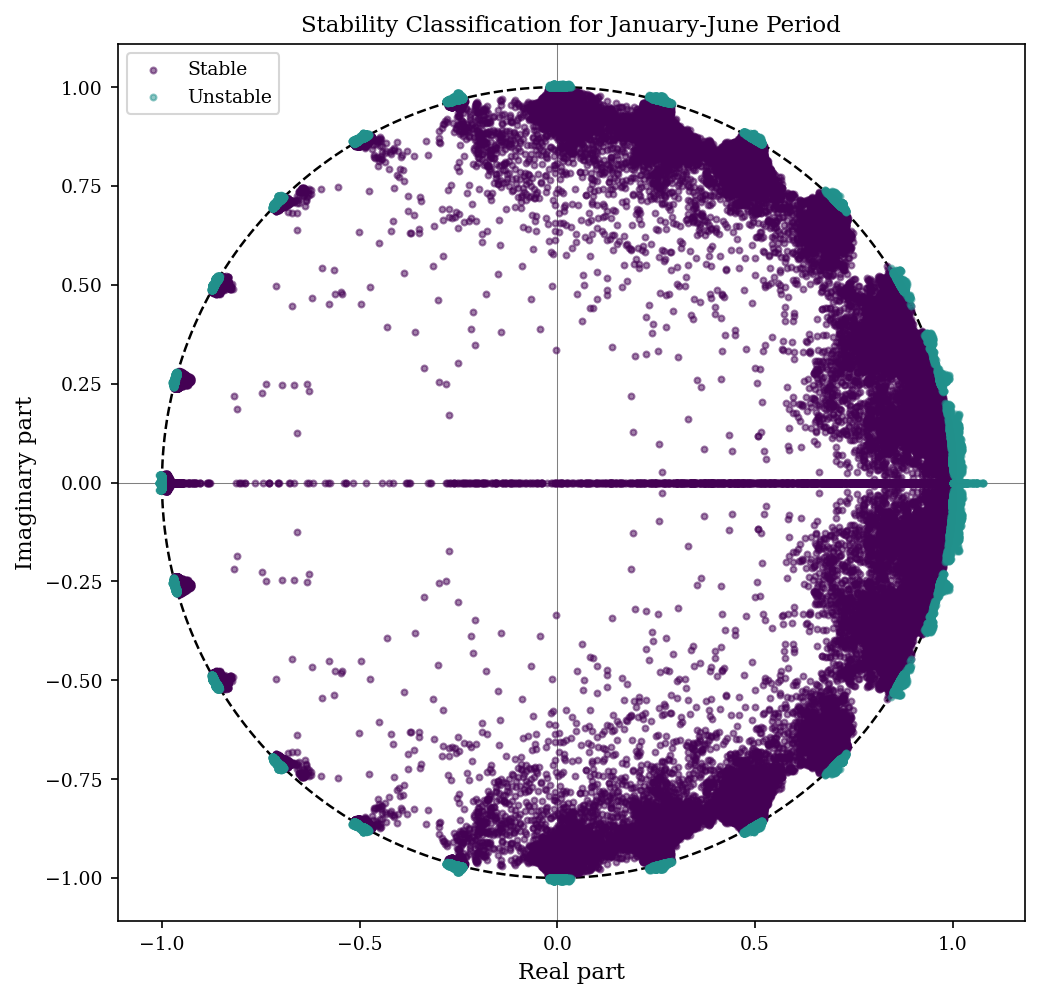

Saved: /content/eigenvalues_stability_rank62(jan-june).png


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from pydmd import HankelDMD

all_eigs = []

for w in range(n_windows):
    start = w * step_size
    end   = start + window_size

    X_window          = data[:, start:end]
    window_mean       = np.mean(X_window, axis=1, keepdims=True)
    X_window_demeaned = X_window - window_mean

    hankel_dmd = HankelDMD(svd_rank=ranks[0], d=d)
    hankel_dmd.fit(X_window_demeaned)
    all_eigs.append(hankel_dmd.eigs)

all_eigs_flat = np.concatenate(all_eigs)
magnitudes    = np.abs(all_eigs_flat)

tol = 0.0   # tolerance band around unit circle: |λ| in [1-tol, 1+tol] = neutral

stable   = all_eigs_flat[magnitudes < 1 - tol]
neutral  = all_eigs_flat[(magnitudes >= 1 - tol) & (magnitudes <= 1 + tol)]
unstable = all_eigs_flat[magnitudes > 1 + tol]

print(f"Stable   (|λ| < {1-tol:.2f}) : {len(stable)}")
print(f"Neutral  (|λ| ≈ 1 ± {tol})   : {len(neutral)}")
print(f"Unstable (|λ| > {1+tol:.2f}) : {len(unstable)}")

# ---- Plot ----
theta = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1.2, zorder=2)
ax.axhline(0, color='gray', lw=0.5, zorder=1)
ax.axvline(0, color='gray', lw=0.5, zorder=1)

if len(stable) > 0:
    ax.scatter(stable.real,   stable.imag,
               color='#440154', s=8, alpha=0.5, zorder=3,
               label=f'Stable')

if len(neutral) > 0:
    ax.scatter(neutral.real,  neutral.imag,
               color='#FDE725',      s=10, alpha=0.7, zorder=4,
               label=f'Neutral')

if len(unstable) > 0:
    ax.scatter(unstable.real, unstable.imag,
               color='#21918C',   s=8, alpha=0.5, zorder=3,
               label=f'Unstable')

ax.set_aspect('equal')
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')
ax.set_title(
    f'Stability Classification for January-June Period'
    #f'(rank={ranks[0]}, d={d}, window={window_size}, {n_windows} windows)'
)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()

plot_path = f"/content/eigenvalues_stability_rank{ranks[0]}(jan-june).png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

In [ ]:

import numpy as np
import openpyxl
from pydmd import HankelDMD

r = ranks[0]

wb = openpyxl.Workbook(write_only=True)
ws_eig = wb.create_sheet("Eigenvalues")

eig_header = ["Window"]
for i in range(r):
    eig_header += [f"Eig{i}_Real", f"Eig{i}_Imag"]
ws_eig.append(eig_header)

ws_amp = wb.create_sheet("Amplitudes")

amp_header = ["Window"]
for i in range(r):
    amp_header += [f"Amp{i}_Real", f"Amp{i}_Imag"]
ws_amp.append(amp_header)

processed_count = 0
skipped_count = 0

for w in range(n_windows):
    start = w * step_size
    end   = start + window_size

    X_window = data[:, start:end]

    if np.isnan(X_window).any():
        print(f"Skipping window {w}: contains NaNs")
        skipped_count += 1
        continue

    window_mean = np.mean(X_window, axis=1, keepdims=True)
    X_window_demeaned = X_window - window_mean

    try:
        # Fit HankelDMD
        hankel_dmd = HankelDMD(svd_rank=r, d=d)
        hankel_dmd.fit(X_window_demeaned)

        eigs = hankel_dmd.eigs
        Phi  = hankel_dmd.modes
        h_0  = hankel_dmd.ho_snapshots[:, -1]
        b    = np.linalg.pinv(Phi) @ h_0

        # --- Eigenvalues row ---
        eig_row = [w]
        for lam in eigs:
            eig_row += [float(lam.real), float(lam.imag)]
        ws_eig.append(eig_row)

        # --- Amplitudes row ---
        amp_row = [w]
        for amp in b:
            amp_row += [float(amp.real), float(amp.imag)]
        ws_amp.append(amp_row)

        processed_count += 1

        if w % 20 == 0:
            print(f"Processed window {w}/{n_windows}")

    except Exception as e:
        print(f"Skipping window {w} due to error: {e}")
        skipped_count += 1
        continue

out_path = f"/content/hankeldmd_eigs_amps_rank{r}_jan-june.xlsx"
wb.save(out_path)


Processed window 0/4219
Processed window 20/4219
Processed window 40/4219
Processed window 60/4219
Processed window 80/4219
Processed window 100/4219
Processed window 120/4219
Processed window 140/4219
Processed window 160/4219
Processed window 180/4219
Processed window 200/4219
Processed window 220/4219
Processed window 240/4219
Processed window 260/4219
Processed window 280/4219
Processed window 300/4219
Processed window 320/4219
Processed window 340/4219
Processed window 360/4219
Processed window 380/4219
Processed window 400/4219
Processed window 420/4219
Processed window 440/4219
Processed window 460/4219
Processed window 480/4219
Processed window 500/4219
Processed window 520/4219
Processed window 540/4219
Processed window 560/4219
Processed window 580/4219
Processed window 600/4219
Processed window 620/4219
Processed window 640/4219
Processed window 660/4219
Processed window 680/4219
Processed window 700/4219
Processed window 720/4219
Processed window 740/4219
Processed window 7

In [ ]:
import pandas as pd
import numpy as np

input_file = "/content/hankeldmd_eigs_amps_rank62_jan-june.xlsx"
output_file = "max_abs_amplitude_eigen_summary_rank62_jan-june.xlsx"

amps_df = pd.read_excel(input_file, sheet_name="Amplitudes")
eigs_df = pd.read_excel(input_file, sheet_name="Eigenvalues")

amp_real_cols = [col for col in amps_df.columns if "_Real" in col and col.startswith("Amp")]
amp_imag_cols = [col for col in amps_df.columns if "_Imag" in col and col.startswith("Amp")]

eig_real_cols = [col for col in eigs_df.columns if "_Real" in col and col.startswith("Eig")]
eig_imag_cols = [col for col in eigs_df.columns if "_Imag" in col and col.startswith("Eig")]

amp_real_cols = sorted(amp_real_cols, key=lambda x: int(x.split("_")[0].replace("Amp", "")))
amp_imag_cols = sorted(amp_imag_cols, key=lambda x: int(x.split("_")[0].replace("Amp", "")))

eig_real_cols = sorted(eig_real_cols, key=lambda x: int(x.split("_")[0].replace("Eig", "")))
eig_imag_cols = sorted(eig_imag_cols, key=lambda x: int(x.split("_")[0].replace("Eig", "")))

r = len(amp_real_cols)

print(f"Detected rank r = {r}")

results = []

for idx in range(len(amps_df)):

    w = amps_df.loc[idx, "Window"] if "Window" in amps_df.columns else idx
    amp_real = amps_df.loc[idx, amp_real_cols].values.astype(float)
    amp_imag = amps_df.loc[idx, amp_imag_cols].values.astype(float)
    amps_complex = amp_real + 1j * amp_imag

    eig_real = eigs_df.loc[idx, eig_real_cols].values.astype(float)
    eig_imag = eigs_df.loc[idx, eig_imag_cols].values.astype(float)
    eigs_complex = eig_real + 1j * eig_imag

    abs_amps = np.abs(amps_complex)
    max_idx = np.argmax(abs_amps)

    max_abs_amp = abs_amps[max_idx]
    dominant_eig = eigs_complex[max_idx]

    results.append({
        "Window": w,
        "MaxAbsoluteAmplitude": max_abs_amp,
        "Eigen_Real": dominant_eig.real,
        "Eigen_Imag": dominant_eig.imag
    })

result_df = pd.DataFrame(results)
result_df.to_excel(output_file, index=False)

print(f"\nSaved summary file as: {output_file}")
print(result_df.head())

Detected rank r = 62

Saved summary file as: max_abs_amplitude_eigen_summary_rank62_jan-june.xlsx
   Window  MaxAbsoluteAmplitude  Eigen_Real  Eigen_Imag
0       0            739.140053    0.961099    0.262140
1       1           1041.670764    0.865930    0.501706
2       2            711.464873    0.962398   -0.263378
3       3            722.971980    0.868017   -0.500898
4       4            915.421091    0.867060    0.500842


Figure saved as:  hankel eigenvalues(jan-june).png


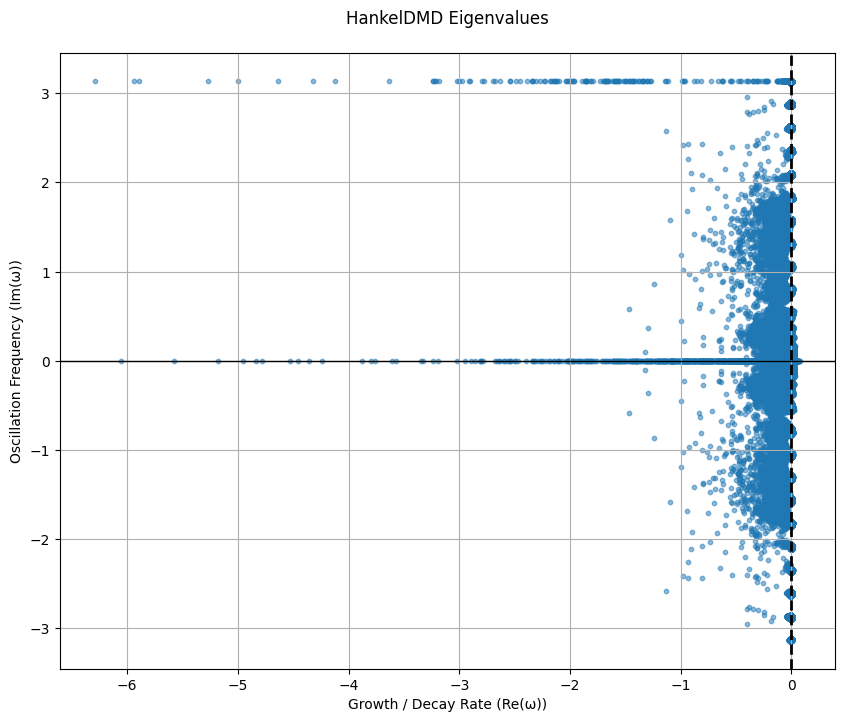

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydmd import HankelDMD

filename         = "/content/trend_plus_seasonal_MSTL(jan-june).xlsx"

window_size      = 120
forecast_horizon = 6
step_size        = 1

d = 48
r = 62
dt = 1

save_path = " hankel eigenvalues(jan-june).png"

df = pd.read_excel(filename)

stations = df.iloc[:, 0].values
data     = df.iloc[:, 1:].values.astype(float)

n_stations, total_snapshots = data.shape

n_windows = (
    total_snapshots
    - window_size
    - forecast_horizon
) // step_size + 1

all_omega = []

for w in range(n_windows):

    start = w * step_size
    end   = start + window_size

    X_window = data[:, start:end]
    window_mean = np.mean(X_window, axis=1, keepdims=True)
    X_demeaned  = X_window - window_mean

    # HankelDMD
    hankel_dmd = HankelDMD(svd_rank=r, d=d )
    hankel_dmd.fit(X_demeaned)
    eigs = hankel_dmd.eigs

    omega = np.log(eigs) / dt
    all_omega.extend(omega)

all_omega = np.array(all_omega)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    all_omega.real,
    all_omega.imag,
    s=10,
    alpha=0.5
)

# Stability boundary
plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label=''
)

# Axes
plt.axhline(0, color='black', linewidth=1)

plt.xlabel("Growth / Decay Rate (Re(ω))")
plt.ylabel("Oscillation Frequency (Im(ω))")

plt.title(
    f"HankelDMD Eigenvalues\n"

)

plt.grid(True)

#plt.legend()

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"Figure saved as: {save_path}")

plt.show()

Saved figure to hankel_reconstruction_window_0(jan-june).png


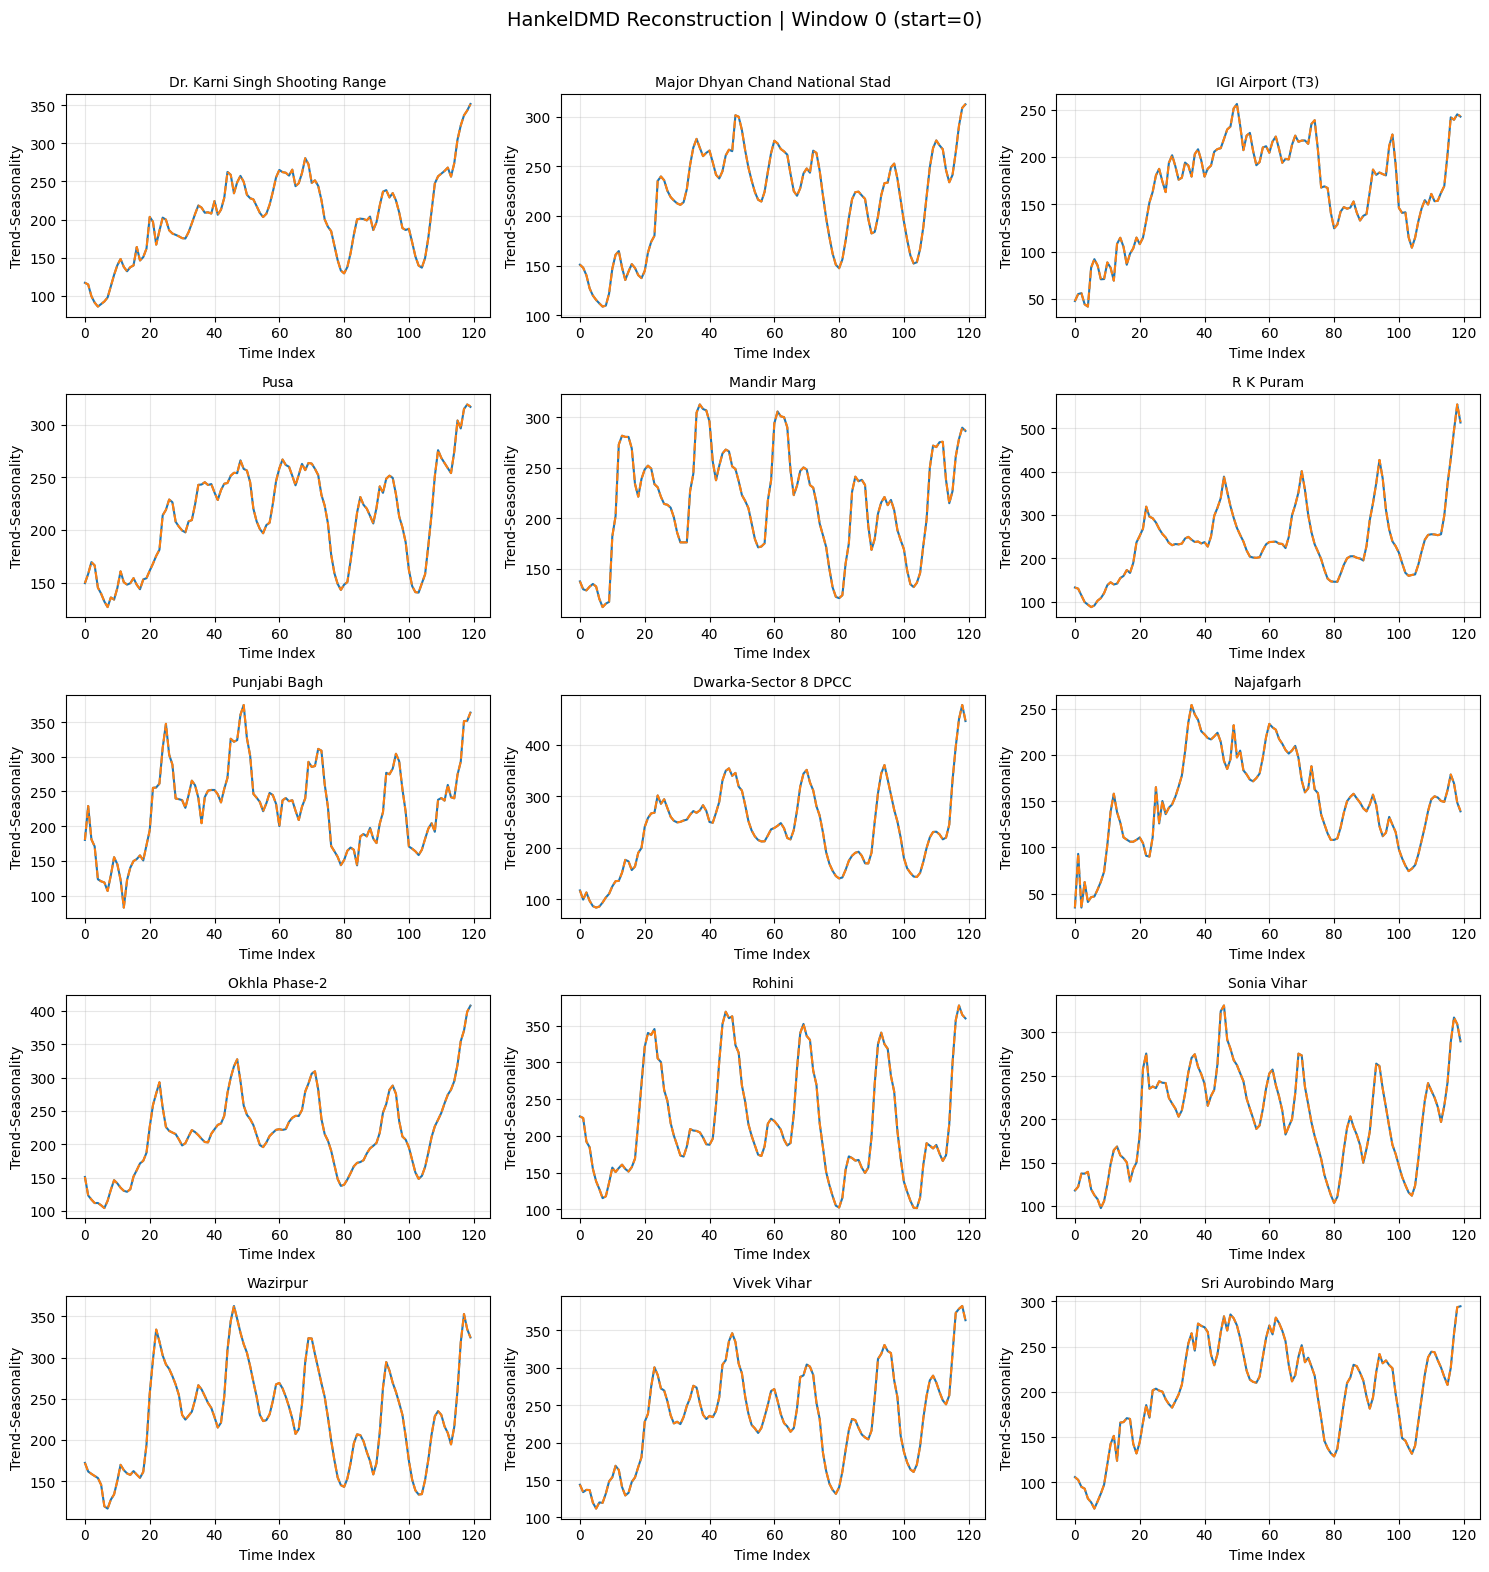

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator


w = 0

start = w * step_size
end   = start + window_size

X_window = data[:, start:end]

window_mean       = np.mean(X_window, axis=1, keepdims=True)
X_window_demeaned = X_window - window_mean

hankel_dmd = HankelDMD(svd_rank=ranks[0], d=d)
hankel_dmd.fit(X_window_demeaned)

Phi  = hankel_dmd.modes
eigs = hankel_dmd.eigs

rec = np.real(hankel_dmd.reconstructed_data[-n_stations:, :])
rec = np.maximum(rec + window_mean, 0)

h_0 = hankel_dmd.ho_snapshots[:, -1]
b   = np.linalg.pinv(Phi) @ h_0

forecasts = np.zeros((n_stations, forecast_horizon))

for k in range(1, forecast_horizon + 1):
    Lambda_k = np.diag(eigs ** k)
    h_k      = Phi @ Lambda_k @ b
    x_next   = np.real(h_k[-n_stations:])
    x_next   = np.maximum(x_next + window_mean[:, 0], 0)
    forecasts[:, k - 1] = x_next

t_rec  = np.arange(start, end)
t_pred = np.arange(end, end + forecast_horizon)

# ============================================================
# PLOT ALL STATIONS IN A DYNAMIC GRID
# ============================================================

ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)  # flatten regardless of shape

for s in range(nrows * ncols):
    ax = axes[s]
    if s < n_stations:

        ax.plot(t_rec, data[s, start:end], label="Observed", color="tab:blue", linewidth=1.5)
        ax.plot(t_rec, rec[s, :], '--', label="Reconstructed", color="tab:orange", linewidth=1.5)

        clean_title = station_labels[s].replace("_", " ").replace("Delhi", "").strip()
        clean_title = " ".join(clean_title.split())
        ax.set_title(clean_title, fontsize=10)

        ax.set_xlabel("Time Index")
        ax.set_ylabel("Trend-Seasonality")

        ax.xaxis.set_major_locator(MultipleLocator(20))
        ax.tick_params(axis='x', labelbottom=True)  # force labels to show on every subplot

        ax.grid(True, alpha=0.3)
        #ax.legend(loc="upper right", fontsize=8)
    else:
        ax.axis("off")  # hide unused subplot slots

fig.suptitle(f"HankelDMD Reconstruction | Window {w} (start={start})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = f"hankel_reconstruction_window_{w}(jan-june).png"
fig.savefig(save_path, dpi=600, bbox_inches="tight")
print(f"Saved figure to {save_path}")

plt.show()

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pydmd import HankelDMD

# ============================================================
# PARAMETERS
# ============================================================

# Choose WINDOW NUMBERS (not start indices)
first_window = 2501        # First window number
last_window = 4219      # Last window number (inclusive)

# ============================================================
# DATA INFORMATION
# ============================================================

n_stations, n_time = data.shape

# Generate the same windows used in the forecasting code
window_starts = list(range(0,n_time - window_size - forecast_horizon + 1,step_size))

total_windows = len(window_starts)

print(f"Total windows available: {total_windows}")

# Make sure requested window numbers are valid
first_window = max(0, first_window)
last_window = min(last_window, total_windows - 1)

print(f"Processing window numbers {first_window} to {last_window}")

# ============================================================
# OUTPUT FOLDER
# ============================================================

output_folder = "HankelDMD_Reconstruction_Plots_2501-4219(jan-june)"
os.makedirs(output_folder, exist_ok=True)

# ============================================================
# LOOP OVER WINDOW NUMBERS
# ============================================================

for w in range(first_window, last_window + 1):

    # Convert window number -> starting index
    start = window_starts[w]
    end = start + window_size

    # --------------------------------------------------------
    # WINDOW
    # --------------------------------------------------------

    X_window = data[:, start:end]

    window_mean = np.mean(X_window, axis=1, keepdims=True)
    X_window_demeaned = X_window - window_mean

    # --------------------------------------------------------
    # FIT HANKELDMD
    # --------------------------------------------------------

    hankel_dmd = HankelDMD(svd_rank=ranks[0],d=d)

    hankel_dmd.fit(X_window_demeaned)

    Phi = hankel_dmd.modes
    eigs = hankel_dmd.eigs

    # --------------------------------------------------------
    # RECONSTRUCTION
    # --------------------------------------------------------

    rec = np.real(hankel_dmd.reconstructed_data[-n_stations:, :])
    rec = np.maximum(rec + window_mean, 0)

    # --------------------------------------------------------
    # FORECAST (optional)
    # --------------------------------------------------------

    h_0 = hankel_dmd.ho_snapshots[:, -1]
    b = np.linalg.pinv(Phi) @ h_0

    forecasts = np.zeros((n_stations, forecast_horizon))

    for k in range(1, forecast_horizon + 1):

        Lambda_k = np.diag(eigs ** k)

        h_k = Phi @ Lambda_k @ b

        x_next = np.real(h_k[-n_stations:])
        x_next = np.maximum(x_next + window_mean[:, 0], 0)

        forecasts[:, k - 1] = x_next

    # --------------------------------------------------------
    # TIME AXIS
    # --------------------------------------------------------

    t_rec = np.arange(start, end)

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    ncols = 3
    nrows = int(np.ceil(n_stations / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True
    )

    axes = np.array(axes).reshape(-1)

    for s in range(nrows * ncols):

        ax = axes[s]

        if s < n_stations:

            ax.plot(
                t_rec,
                data[s, start:end],
                color="tab:blue",
                linewidth=1.5
            )

            ax.plot(
                t_rec,
                rec[s],
                "--",
                color="tab:orange",
                linewidth=1.5
            )

            clean_title = (station_labels[s].replace("_", " ").replace("Delhi", "").strip())
            clean_title = " ".join(clean_title.split())

            ax.set_title(clean_title, fontsize=10)

            ax.set_xlabel("Time Index")
            ax.set_ylabel("Trend-Seasonality")

            ax.xaxis.set_major_locator(MultipleLocator(20))
            ax.tick_params(axis="x", labelbottom=True)

            ax.grid(True, alpha=0.3)

        else:
            ax.axis("off")

    fig.suptitle(
        f"HankelDMD Reconstruction | Window {w} (Start Index = {start})",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # --------------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------------

    filename = os.path.join(
        output_folder,
        f"window_{w:04d}.png"
    )

    fig.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    print(f"Saved window {w} -> {filename}")

# ============================================================
# CREATE ZIP FILE
# ============================================================

zip_filename = "HankelDMD_Reconstruction_Plots_2501-4219(jan-june).zip"

with zipfile.ZipFile(
    zip_filename,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in sorted(os.listdir(output_folder)):
        filepath = os.path.join(output_folder, file)
        zipf.write(filepath, arcname=file)

print(f"\nZIP file created successfully: {zip_filename}")

Prediction of HanklDMD for trend+seasonality


In [ ]:
#!pip install PyDMD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydmd import HankelDMD
from collections import defaultdict
import openpyxl

filename = "/content/rearranged(jan-june)_dmd.xlsx"

window_size = 120
forecast_horizon = 6
step_size = 1
d = 48

ranks = [62]


df = pd.read_excel(filename)
stations = df.iloc[:, 0].values
data = df.iloc[:, 1:].values.astype(float)

n_stations, total_snapshots = data.shape


for r in ranks:
    ensemble_preds = defaultdict(lambda: defaultdict(list))
    horizon_preds = defaultdict(lambda: defaultdict(dict))

    n_windows = (total_snapshots - window_size - forecast_horizon) // step_size + 1

    for w in range(n_windows):

        start = w * step_size
        end   = start + window_size

        X_window          = data[:, start:end]
        window_mean       = np.mean(X_window, axis=1, keepdims=True)
        X_window_demeaned = X_window - window_mean

        hankel_dmd = HankelDMD(svd_rank=r, d=d)
        hankel_dmd.fit(X_window_demeaned)

        Phi  = hankel_dmd.modes
        eigs = hankel_dmd.eigs

        h_0 = hankel_dmd.ho_snapshots[:, -1]
        b   = np.linalg.pinv(Phi) @ h_0

        for k in range(1, forecast_horizon + 1):
            t_idx = end + k - 1

            if t_idx >= total_snapshots:
                continue

            Lambda_k = np.diag(eigs ** k)
            h_k      = Phi @ Lambda_k @ b
            x_next   = np.real(h_k[-n_stations:])
            x_next   = np.maximum(x_next + window_mean[:, 0], 0)

            for s in range(n_stations):
                ensemble_preds[t_idx][s].append(x_next[s])
                horizon_preds[s][k][t_idx] = x_next[s]

    ensemble_nrmse_range = np.zeros(n_stations)
    ensemble_nrmse_std   = np.zeros(n_stations)
    ensemble_mape        = np.zeros(n_stations)

    for s in range(n_stations):
        t_indices = sorted(ensemble_preds.keys())

        y_true = []
        y_pred = []

        for t in t_indices:
            #if t < total_snapshots and s in ensemble_preds[t]:
            if t < total_snapshots and len(ensemble_preds[t][s]) > 0:
                y_true.append(data[s, t])
                y_pred.append(np.mean(ensemble_preds[t][s]))

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

        ensemble_nrmse_range[s] = rmse / (np.max(y_true) - np.min(y_true))
        ensemble_nrmse_std[s]   = rmse #/ np.std(y_true)

        mask = y_true != 0
        ensemble_mape[s] = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    # results[s][k] = (nrmse_std, nrmse_range, mape)
    horizon_results = defaultdict(dict)

    for s in range(n_stations):
        for k in range(1, forecast_horizon + 1):

            t_dict    = horizon_preds[s][k]
            t_indices = sorted(t_dict.keys())

            y_true = np.array([data[s, t] for t in t_indices])
            y_pred = np.array([t_dict[t]  for t in t_indices])

            rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

            nrmse_std   = rmse #/ np.std(y_true)
            nrmse_range = rmse / (np.max(y_true) - np.min(y_true))

            mask = y_true != 0
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

            horizon_results[s][k] = (nrmse_std, nrmse_range, mape)

    output_filename = f"/content/errors_rank{r}(jan-june).xlsx"

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = f"Rank_{r}"

    # Header row
    header = ["Station"]
    for k in range(1, forecast_horizon + 1):
        header += [f"k={k} RMSE", f"k={k} NRMSE(range)", f"k={k} MAPE(%)"]
    header += ["Ensemble RMSE", "Ensemble NRMSE(range)", "Ensemble MAPE(%)"]
    ws.append(header)

    # Data rows
    for s in range(n_stations):
        row = [stations[s]]
        for k in range(1, forecast_horizon + 1):
            nrmse_std, nrmse_range, mape = horizon_results[s][k]
            row += [round(nrmse_std, 4), round(nrmse_range, 4), round(mape, 2)]
        row += [
            round(ensemble_nrmse_std[s], 4),
            round(ensemble_nrmse_range[s], 4),
            round(ensemble_mape[s], 2)
        ]
        ws.append(row)

    wb.save(output_filename)
    print(f"Saved: {output_filename}")


    pred_output_filename = f"/content/predictions_rank{r}(jan-june).xlsx"

    all_t_indices = sorted(ensemble_preds.keys())

    pred_matrix = np.full((n_stations, len(all_t_indices)), np.nan)

    for j, t in enumerate(all_t_indices):
        for s in range(n_stations):
            if len(ensemble_preds[t][s]) > 0:
                pred_matrix[s, j] = np.mean(ensemble_preds[t][s])

    wb_pred = openpyxl.Workbook()
    ws_pred = wb_pred.active
    ws_pred.title = f"Rank_{r}_Predictions"

    # Header row: Station, then one column per time index
    header_pred = ["Station"] + [f"t={t}" for t in all_t_indices]
    ws_pred.append(header_pred)

    # Data rows
    for s in range(n_stations):
        row = [stations[s]] + [
            round(pred_matrix[s, j], 4) if not np.isnan(pred_matrix[s, j]) else None
            for j in range(len(all_t_indices))
        ]
        ws_pred.append(row)

    wb_pred.save(pred_output_filename)
    print(f"Saved: {pred_output_filename}")

Saved: /content/errors_rank62(jan-june).xlsx
Saved: /content/predictions_rank62(jan-june).xlsx


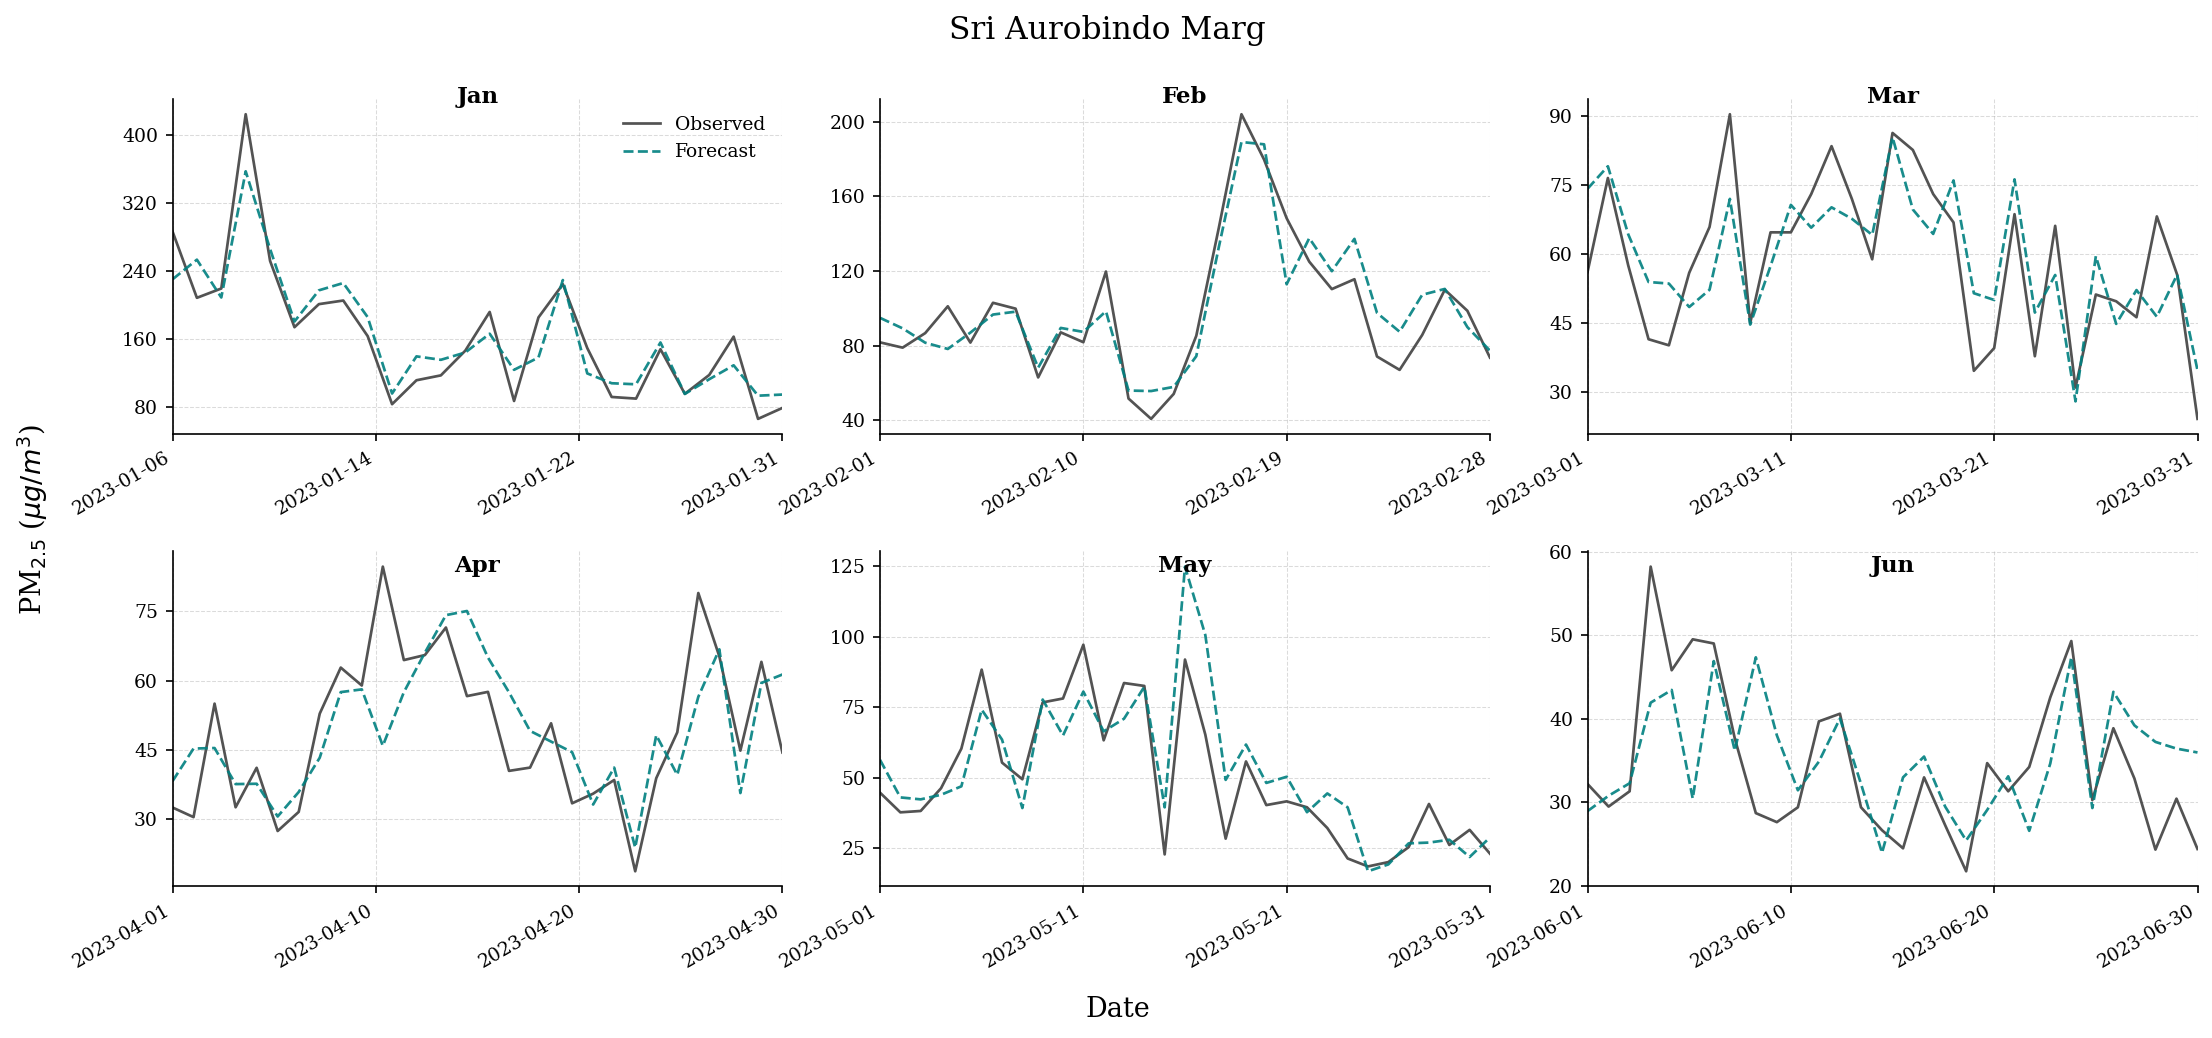

Saved: /content/publication_plots_rank62/Sri_Aurobindo_Marg_Delhi_forecasts_daily_original(jan-june).png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from collections import defaultdict
from datetime import datetime, timedelta

save_folder = f"/content/publication_plots_rank{r}"
os.makedirs(save_folder, exist_ok=True)

station_index = 14


start_date = datetime(2023, 1, 1)

month_windows_hourly = {
    "Jan": (0, 744),
    "Feb": (744, 1416),
    "Mar": (1416, 2160),
    "Apr": (2160, 2880),
    "May": (2880, 3624),
    "Jun": (3624, 4344)
}

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 500,
    "axes.linewidth": 0.8
})

# ============================================================
# CREATE 2x3 FIGURE
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=False)
axes = axes.flatten()

# ============================================================
# BUILD DAILY SERIES DIRECTLY FROM ensemble_preds
# ============================================================
# day_true[day]  -> list of hourly true values for that day
# day_pred[day]  -> list of hourly ensemble-mean values for that day
# Only days with a FULL 24 hours of predictions are kept, so
# partial days near window edges don't skew the daily average.

day_true = defaultdict(list)
day_pred = defaultdict(list)

for t in sorted(ensemble_preds.keys()):

    preds = ensemble_preds[t][station_index]

    if t < total_snapshots and len(preds) > 0:
        day = t // 24
        day_true[day].append(data[station_index, t])
        day_pred[day].append(np.mean(preds))

x_daily, y_true_daily, y_mean_daily = [], [], []

for day in sorted(day_true.keys()):
    if len(day_true[day]) == 24:  # require a complete day
        x_daily.append(day)
        y_true_daily.append(np.mean(day_true[day]))
        y_mean_daily.append(np.mean(day_pred[day]))

x_daily      = np.array(x_daily)       # day index (0 = first day)
y_true_daily = np.array(y_true_daily)
y_mean_daily = np.array(y_mean_daily)

# Convert day indices -> actual dates
dates_daily = np.array([start_date + timedelta(days=int(d)) for d in x_daily])

# Convert month windows from hours -> days
month_windows = {
    m: (s // 24, e // 24) for m, (s, e) in month_windows_hourly.items()
}

# ============================================================
# LOOP THROUGH MONTHS
# ============================================================

for ax, (month, (start, end)) in zip(axes, month_windows.items()):

    mask = (x_daily >= start) & (x_daily < end)

    x_plot   = dates_daily[mask]      # dates instead of day index
    y_true_p = y_true_daily[mask]
    y_mean_p = y_mean_daily[mask]

    ax.plot(x_plot, y_true_p, color="#404040", linewidth=1.3, alpha=0.9, label="Observed")
    ax.plot(x_plot, y_mean_p, color="#008080", linestyle="--", linewidth=1.3, alpha=0.9, label="Forecast")

    y_min = min(y_true_p.min(), y_mean_p.min())
    y_max = max(y_true_p.max(), y_mean_p.max())
    padding = 0.05 * (y_max - y_min)
    ax.set_ylim(y_min - padding, y_max + padding)

    title_y = 0.9 if month in ["Apr", "May", "Jun"] else 0.95
    ax.set_title(month, fontweight="bold", fontsize=11, y=title_y)

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---- Date axis: force ticks to stay within the actual data range ----
    ax.set_xlim(x_plot[0], x_plot[-1])   # clamp axis to first/last actual date

    n_ticks = 4
    tick_positions = mdates.date2num(
        [x_plot[0] + (x_plot[-1] - x_plot[0]) * i / (n_ticks - 1) for i in range(n_ticks)]
    )
    ax.set_xticks(tick_positions)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.tick_params(axis='y', labelleft=True)

# ============================================================
# COMMON LABELS
# ============================================================

fig.supxlabel("Date", fontsize=13, y=0.02)
fig.supylabel(r"PM$_{2.5}$ ($\mu g/m^3$)", fontsize=13, x=0.01)

axes[0].legend(frameon=False, loc="upper right")

fig.suptitle(
    str(stations[station_index]).replace("_", " ").replace("Delhi"," "),
    fontsize=15,
    y=0.98
)

plt.subplots_adjust(left=0.08, right=0.98, bottom=0.15, top=0.90, hspace=0.35, wspace=0.16)

# ============================================================
# SAVE FIGURE
# ============================================================

safe_station_name = (
    str(stations[station_index]).replace("/", "_").replace("\\", "_").replace(" ", "_")
)

save_path = os.path.join(save_folder, f"{safe_station_name}_forecasts_daily_original(jan-june).png")
fig.savefig(save_path, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved: {save_path}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from collections import defaultdict
from datetime import datetime, timedelta

# ============================================================
# SETTINGS
# ============================================================

save_folder = f"/content/publication_plots_rank{r}"
os.makedirs(save_folder, exist_ok=True)

# ============================================================
# CHOOSE STATION
# ============================================================

station_index = 14
# ============================================================
# START DATE (day 0 of your data corresponds to this date)
# ============================================================

start_date = datetime(2023, 8, 1)   # <-- set this to match your actual data start (Aug 1 here)

# ============================================================
# MONTH WINDOWS (in HOURS -> will convert to DAYS below)
# ============================================================

month_windows_hourly = {
    "Aug": (0, 744),
    "Sep": (744, 1464),
    "Oct": (1464, 2208),
    "Nov": (2208, 2928),
    "Dec": (2928, 3672)
}

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 500,
    "axes.linewidth": 0.8
})

# ============================================================
# CREATE CUSTOM LAYOUT (3 top, 2 centered bottom)
# ============================================================

fig = plt.figure(figsize=(15, 7))

gs = gridspec.GridSpec(
    2,
    6,
    figure=fig
)

# ------------------------------------------------------------
# TOP ROW
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0:2])   # Aug
ax2 = fig.add_subplot(gs[0, 2:4])   # Sep
ax3 = fig.add_subplot(gs[0, 4:6])   # Oct

# ------------------------------------------------------------
# BOTTOM ROW (CENTERED)
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[1, 1:3])   # Nov
ax5 = fig.add_subplot(gs[1, 3:5])   # Dec

axes = [ax1, ax2, ax3, ax4, ax5]

# ============================================================
# BUILD DAILY SERIES DIRECTLY FROM ensemble_preds
# ============================================================
# day_true[day]  -> list of hourly true values for that day
# day_pred[day]  -> list of hourly ensemble-mean values for that day
# Only days with a FULL 24 hours of predictions are kept, so
# partial days near window edges don't skew the daily average.

day_true = defaultdict(list)
day_pred = defaultdict(list)

for t in sorted(ensemble_preds.keys()):

    preds = ensemble_preds[t][station_index]

    if t < total_snapshots and len(preds) > 0:
        day = t // 24
        day_true[day].append(data[station_index, t])
        day_pred[day].append(np.mean(preds))

x_daily, y_true_daily, y_mean_daily = [], [], []

for day in sorted(day_true.keys()):
    if len(day_true[day]) == 24:  # require a complete day
        x_daily.append(day)
        y_true_daily.append(np.mean(day_true[day]))
        y_mean_daily.append(np.mean(day_pred[day]))

x_daily      = np.array(x_daily)       # day index (0 = first day)
y_true_daily = np.array(y_true_daily)
y_mean_daily = np.array(y_mean_daily)

# Convert day indices -> actual dates
dates_daily = np.array([start_date + timedelta(days=int(d)) for d in x_daily])

# Convert month windows from hours -> days
month_windows = {
    m: (s // 24, e // 24) for m, (s, e) in month_windows_hourly.items()
}

# ============================================================
# LOOP THROUGH MONTHS
# ============================================================

for ax, (month, (start, end)) in zip(axes, month_windows.items()):

    # --------------------------------------------------------
    # SELECT MONTH WINDOW
    # --------------------------------------------------------

    mask = (x_daily >= start) & (x_daily < end)

    x_plot   = dates_daily[mask]      # dates instead of day index
    y_true_p = y_true_daily[mask]
    y_mean_p = y_mean_daily[mask]

    # --------------------------------------------------------
    # OBSERVED SIGNAL
    # --------------------------------------------------------

    ax.plot(
        x_plot,
        y_true_p,
        color="#404040",
        linewidth=1.3,
        alpha=0.9,
        #label="Observed"
    )

    # --------------------------------------------------------
    # FORECAST SIGNAL
    # --------------------------------------------------------

    ax.plot(
        x_plot,
        y_mean_p,
        color="#008080",
        linestyle="--",
        linewidth=1.3,
        alpha=0.9,
        #label="Forecast"
    )

    # --------------------------------------------------------
    # Y-LIMITS WITH PADDING
    # --------------------------------------------------------

    y_min = min(y_true_p.min(), y_mean_p.min())
    y_max = max(y_true_p.max(), y_mean_p.max())
    padding = 0.05 * (y_max - y_min)
    ax.set_ylim(y_min - padding, y_max + padding)

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    title_y = 0.92 if month in ["Nov", "Dec"] else 0.95

    ax.set_title(
        month,
        fontsize=12,
        fontweight="bold",
        y=title_y
    )

    # --------------------------------------------------------
    # GRID
    # --------------------------------------------------------

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.45
    )

    # --------------------------------------------------------
    # CLEAN SPINES
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # DATE AXIS: force ticks to stay within actual data range
    # --------------------------------------------------------

    ax.set_xlim(x_plot[0], x_plot[-1])   # clamp axis to first/last actual date

    n_ticks = 4
    tick_positions = mdates.date2num(
        [x_plot[0] + (x_plot[-1] - x_plot[0]) * i / (n_ticks - 1) for i in range(n_ticks)]
    )
    ax.set_xticks(tick_positions)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    # --------------------------------------------------------
    # Y TICKS
    # --------------------------------------------------------

    ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.tick_params(
        axis='y',
        labelleft=True
    )

# ============================================================
# COMMON LABELS
# ============================================================

fig.supxlabel(
    "Date",
    fontsize=13,
    y=0.02
)

fig.supylabel(
    r"PM$_{2.5}$ ($\mu g/m^3$)",
    fontsize=13,
    x=0.01
)

# ============================================================
# LEGEND
# ============================================================

axes[0].legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.02, 1.02)
)

# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    str(stations[station_index]).replace("_", " "),
    fontsize=14,
    y=0.98
)

# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.15,
    top=0.9,
    hspace=0.45,
    wspace=0.35
)

# ============================================================
# SAVE FIGURE
# ============================================================

safe_station_name = (
    str(stations[station_index])
    .replace("/", "_")
    .replace("\\", "_")
    .replace(" ", "_")
)

save_path = os.path.join(
    save_folder,
    f"{safe_station_name}_forecasts_daily_original(aug-dec).png"
)

fig.savefig(
    save_path,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Saved: {save_path}")

AR model error predictions


In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

window_size = 168
forecast_horizon = 6
step_size = 1
max_lag = 24
ensemble_predictions = {}
rmse_summary = []

for station in stations:

    print(f"Processing {station}")

    residual = mstl_results[station]["residual"].values

    ensemble_preds = defaultdict(list)

    n_windows = (
        len(residual)
        - window_size
        - forecast_horizon
    ) // step_size + 1

    # ---------------------------------
    # Sliding windows
    # ---------------------------------
    for start in range(0, n_windows * step_size, step_size):

        train = residual[start:start + window_size]

        test = residual[
            start + window_size:
            start + window_size + forecast_horizon
        ]

        # -----------------------------
        # BIC order selection
        # -----------------------------
        sel = ar_select_order(
            train,
            maxlag=max_lag,
            ic='bic',
            old_names=False
        )

        if sel.ar_lags is None:
            p = 1
        else:
            p = max(sel.ar_lags)

        # -----------------------------
        # Fit model
        # -----------------------------
        model = AutoReg(
            train,
            lags=p,
            old_names=False
        ).fit()

        pred = model.forecast(steps=forecast_horizon)

        # -----------------------------
        # Store forecasts
        # -----------------------------
        for k in range(forecast_horizon):

            t = start + window_size + k

            ensemble_preds[t].append(pred[k])

    # =================================
    # Ensemble prediction
    # =================================
    times = sorted(ensemble_preds.keys())

    ensemble = np.array([
        np.mean(ensemble_preds[t])
        for t in times
    ])

    truth = residual[times]

    rmse = np.sqrt(
        mean_squared_error(
            truth,
            ensemble
        )
    )

    print(f"RMSE = {rmse:.4f}")

    rmse_summary.append({
        "Station": station,
        "RMSE": rmse
    })


    ensemble_predictions[station] = pd.DataFrame({
        "TimeIndex": times,
        "TrueResidual": truth,
        "EnsemblePrediction": ensemble
    })

output_file = "AR_Ensemble_Residual_Forecasts(jan-june)_168.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:


    pd.DataFrame(rmse_summary).to_excel(
        writer,
        sheet_name="RMSE_Summary",
        index=False
    )

    for station, df in ensemble_predictions.items():

        sheet = str(station)[:31]

        df.to_excel(
            writer,
            sheet_name=sheet,
            index=False
        )

print(f"\nResults saved to {output_file}")

Processing Dr._Karni_Singh_Shooting_Range_
RMSE = 18.5626
Processing Major_Dhyan_Chand_National_Stad
RMSE = 17.1821
Processing IGI_Airport_(T3)_Delhi
RMSE = 19.8937
Processing Pusa_Delhi
RMSE = 18.5541
Processing Mandir_Marg_Delhi
RMSE = 18.2494
Processing R_K_Puram_Delhi
RMSE = 28.4254
Processing Punjabi_Bagh_Delhi
RMSE = 23.5316
Processing Dwarka-Sector_8_Delhi_DPCC
RMSE = 23.0949
Processing Najafgarh_Delhi
RMSE = 18.2221
Processing Okhla_Phase-2_Delhi
RMSE = 18.7498
Processing Rohini_Delhi
RMSE = 26.9077
Processing Sonia_Vihar_Delhi
RMSE = 21.7233
Processing Wazirpur_Delhi
RMSE = 25.6124
Processing Vivek_Vihar_Delhi
RMSE = 26.6899
Processing Sri_Aurobindo_Marg_Delhi
RMSE = 17.6866

Results saved to AR_Ensemble_Residual_Forecasts(jan-june)_168.xlsx


Hourly predicted plots of combined forecasts

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = "combined predictions(jan-june).xlsx"
save_folder = "publication_plots"
os.makedirs(save_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

xls = pd.ExcelFile(DATA_PATH)
obs_df = xls.parse("observed")
pred_df = xls.parse("predicted")

stations = obs_df["Unnamed: 0"].tolist()
time_cols = obs_df.columns[1:]                 # all timestamp columns
time_index = pd.to_datetime(time_cols)

# ============================================================
# CHOOSE STATION(S) TO PLOT
# ============================================================
# Set to a list of indices, or "all" to generate one figure per station.

station_indices = "all"   # e.g. [0, 1, 2] or "all"

if station_indices == "all":
    station_indices = list(range(len(stations)))

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 500,
    "axes.linewidth": 0.8
})

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

# ============================================================
# LOOP OVER STATIONS
# ============================================================

for station_index in station_indices:

    station_name = stations[station_index]

    y_true = obs_df.iloc[station_index, 1:].astype(float).values
    y_pred = pred_df.iloc[station_index, 1:].astype(float).values

    # --------------------------------------------------------
    # CREATE 2x3 FIGURE
    # --------------------------------------------------------

    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=False)
    axes = axes.flatten()

    # --------------------------------------------------------
    # LOOP THROUGH MONTHS (by calendar month, not fixed hour offsets,
    # since the series starts on 2023-01-05, not Jan 1)
    # --------------------------------------------------------

    for ax, month_num in zip(axes, range(1, 7)):

        mask = time_index.month == month_num

        x_plot = time_index[mask]
        y_true_p = y_true[mask]
        y_pred_p = y_pred[mask]

        if len(x_plot) == 0:
            ax.set_visible(False)
            continue

        # ----------------------------------------------------
        # OBSERVED SIGNAL
        # ----------------------------------------------------

        ax.plot(
            x_plot,
            y_true_p,
            color="#404040",
            linewidth=1.3,
            alpha=0.9,
            label="Observed"
        )

        # ----------------------------------------------------
        # FORECAST / PREDICTED SIGNAL
        # ----------------------------------------------------

        ax.plot(
            x_plot,
            y_pred_p,
            color="#008080",
            linestyle="--",
            linewidth=1.3,
            alpha=0.9,
            label="Predicted"
        )

        y_min = min(y_true_p.min(), y_pred_p.min())
        y_max = max(y_true_p.max(), y_pred_p.max())
        padding = 0.05 * (y_max - y_min)
        ax.set_ylim(y_min - padding, y_max + padding)

        # ----------------------------------------------------
        # TITLE
        # ----------------------------------------------------

        month = month_names[month_num - 1]
        title_y = 0.9 if month in ["Apr", "May", "Jun"] else 0.95
        ax.set_title(month, fontweight="bold", fontsize=11, y=title_y)

        # ----------------------------------------------------
        # GRID
        # ----------------------------------------------------

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)

        # ----------------------------------------------------
        # CLEAN SPINES
        # ----------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # ----------------------------------------------------
        # TICKS
        # ----------------------------------------------------

        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.tick_params(axis='y', labelleft=True)
        ax.tick_params(axis='x', rotation=30)

    # --------------------------------------------------------
    # COMMON LABELS
    # --------------------------------------------------------

    fig.supxlabel("Date", fontsize=13, y=0.02)
    fig.supylabel(r"PM$_{2.5}$ ($\mu g/m^3$)", fontsize=13, x=0.04)

    # --------------------------------------------------------
    # LEGEND
    # --------------------------------------------------------

    axes[0].legend(frameon=False, loc="upper right")

    # --------------------------------------------------------
    # MAIN TITLE
    # --------------------------------------------------------

    fig.suptitle(station_name.replace("_", " "), fontsize=15, y=0.98)

    # --------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------

    plt.subplots_adjust(
        left=0.08, right=0.98, bottom=0.15, top=0.90,
        hspace=0.25, wspace=0.16
    )

    # --------------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------------

    safe_station_name = (
        station_name.replace("/", "_").replace("\\", "_").replace(" ", "_")
    )

    save_path = os.path.join(
        save_folder, f"{safe_station_name}_(jan-june).png"
    )

    fig.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {save_path}")


Saved: publication_plots/Dr._Karni_Singh_Shooting_Range__(jan-june).png
Saved: publication_plots/Major_Dhyan_Chand_National_Stad_(jan-june).png
Saved: publication_plots/IGI_Airport_(T3)_Delhi_(jan-june).png
Saved: publication_plots/Pusa_Delhi_(jan-june).png
Saved: publication_plots/Mandir_Marg_Delhi_(jan-june).png
Saved: publication_plots/R_K_Puram_Delhi_(jan-june).png
Saved: publication_plots/Punjabi_Bagh_Delhi_(jan-june).png
Saved: publication_plots/Dwarka-Sector_8_Delhi_DPCC_(jan-june).png
Saved: publication_plots/Najafgarh_Delhi_(jan-june).png
Saved: publication_plots/Okhla_Phase-2_Delhi_(jan-june).png
Saved: publication_plots/Rohini_Delhi_(jan-june).png
Saved: publication_plots/Sonia_Vihar_Delhi_(jan-june).png
Saved: publication_plots/Wazirpur_Delhi_(jan-june).png
Saved: publication_plots/Vivek_Vihar_Delhi_(jan-june).png
Saved: publication_plots/Sri_Aurobindo_Marg_Delhi_(jan-june).png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = "combined prediction(aug-dec).xlsx"
save_folder = "publication_plots_aug_dec"
os.makedirs(save_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

xls = pd.ExcelFile(DATA_PATH)
obs_df = xls.parse("observed")
pred_df = xls.parse("predictions")   # note: sheet name differs from jan-jun file

stations = obs_df["Unnamed: 0"].tolist()
time_cols = obs_df.columns[1:]                 # all timestamp columns
time_index = pd.to_datetime(time_cols)

# ============================================================
# CHOOSE STATION(S) TO PLOT
# ============================================================
# Set to a list of indices, or "all" to generate one figure per station.

station_indices = "all"   # e.g. [0, 1, 2] or "all"

if station_indices == "all":
    station_indices = list(range(len(stations)))

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 500,
    "axes.linewidth": 0.8
})

# Data spans Aug-Dec (5 months)
month_nums = [8, 9, 10, 11, 12]
month_names = ["Aug", "Sep", "Oct", "Nov", "Dec"]

# ============================================================
# LOOP OVER STATIONS
# ============================================================

for station_index in station_indices:

    station_name = stations[station_index]

    y_true = obs_df.iloc[station_index, 1:].astype(float).values
    y_pred = pred_df.iloc[station_index, 1:].astype(float).values

    # --------------------------------------------------------
    # CREATE FIGURE WITH A 2x6 GRIDSPEC
    # Top row: Aug, Sep, Oct -> each spans 2 of 6 columns (0-1, 2-3, 4-5)
    # Bottom row: Nov, Dec -> centered by spanning columns (1-3, 3-5)
    # This visually centers the 2 bottom plots under the 3 top plots.
    # --------------------------------------------------------

    fig = plt.figure(figsize=(15, 7))
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.6)

    # top row axes (Aug, Sep, Oct)
    ax_aug = fig.add_subplot(gs[0, 0:2])
    ax_sep = fig.add_subplot(gs[0, 2:4])
    ax_oct = fig.add_subplot(gs[0, 4:6])

    # bottom row axes (Nov, Dec) - centered, each spanning 2 columns
    # offset by 1 column so the pair sits centered under the 3 top plots
    ax_nov = fig.add_subplot(gs[1, 1:3])
    ax_dec = fig.add_subplot(gs[1, 3:5])

    axes_in_order = [ax_aug, ax_sep, ax_oct, ax_nov, ax_dec]

    # --------------------------------------------------------
    # LOOP THROUGH MONTHS (by calendar month)
    # --------------------------------------------------------

    for ax, month_num, month in zip(axes_in_order, month_nums, month_names):

        mask = time_index.month == month_num

        x_plot = time_index[mask]
        y_true_p = y_true[mask]
        y_pred_p = y_pred[mask]

        if len(x_plot) == 0:
            ax.set_visible(False)
            continue

        # ----------------------------------------------------
        # OBSERVED SIGNAL
        # ----------------------------------------------------

        ax.plot(
            x_plot,
            y_true_p,
            color="#404040",
            linewidth=1.3,
            alpha=0.9,
            label="Observed"
        )

        # ----------------------------------------------------
        # FORECAST / PREDICTED SIGNAL
        # ----------------------------------------------------

        ax.plot(
            x_plot,
            y_pred_p,
            color="#008080",
            linestyle="--",
            linewidth=1.3,
            alpha=0.9,
            label="Predicted"
        )

        y_min = min(y_true_p.min(), y_pred_p.min())
        y_max = max(y_true_p.max(), y_pred_p.max())
        padding = 0.05 * (y_max - y_min)
        ax.set_ylim(y_min - padding, y_max + padding)

        # ----------------------------------------------------
        # TITLE
        # ----------------------------------------------------

        title_y = 0.9 if month in ["Nov", "Dec"] else 0.95
        ax.set_title(month, fontweight="bold", fontsize=11, y=title_y)

        # ----------------------------------------------------
        # GRID
        # ----------------------------------------------------

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)

        # ----------------------------------------------------
        # CLEAN SPINES
        # ----------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # ----------------------------------------------------
        # TICKS
        # ----------------------------------------------------

        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.tick_params(axis='y', labelleft=True)
        ax.tick_params(axis='x', rotation=30)

    # --------------------------------------------------------
    # COMMON LABELS
    # --------------------------------------------------------

    fig.supxlabel("Date", fontsize=13, y=0.02)
    fig.supylabel(r"PM$_{2.5}$ ($\mu g/m^3$)", fontsize=13, x=0.04)

    # --------------------------------------------------------
    # LEGEND
    # --------------------------------------------------------

    ax_aug.legend(frameon=False, loc="upper right")

    # --------------------------------------------------------
    # MAIN TITLE
    # --------------------------------------------------------

    fig.suptitle(station_name.replace("_", " "), fontsize=15, y=0.98)

    # --------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------

    plt.subplots_adjust(
        left=0.08, right=0.98, bottom=0.15, top=0.90
    )

    # --------------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------------

    safe_station_name = (
        station_name.replace("/", "_").replace("\\", "_").replace(" ", "_")
    )

    save_path = os.path.join(
        save_folder, f"{safe_station_name}(aug-dec).png"
    )

    fig.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {save_path}")

hourly average(daily) plots for combined forecasts

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = "combined predictions(jan-june).xlsx"
save_folder = "publication_plots_daily"
os.makedirs(save_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

xls = pd.ExcelFile(DATA_PATH)
obs_df = xls.parse("observed")
pred_df = xls.parse("predicted")

stations = obs_df["Unnamed: 0"].tolist()
time_cols = obs_df.columns[1:]                 # all timestamp columns
time_index = pd.to_datetime(time_cols)

# ============================================================
# CHOOSE STATION(S) TO PLOT
# ============================================================
# Set to a list of indices, or "all" to generate one figure per station.

station_indices = "all"   # e.g. [0, 1, 2] or "all"

if station_indices == "all":
    station_indices = list(range(len(stations)))

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 500,
    "axes.linewidth": 0.8
})

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

# ============================================================
# LOOP OVER STATIONS
# ============================================================

for station_index in station_indices:

    station_name = stations[station_index]

    y_true = obs_df.iloc[station_index, 1:].astype(float).values
    y_pred = pred_df.iloc[station_index, 1:].astype(float).values

    # --------------------------------------------------------
    # AGGREGATE HOURLY -> DAILY (mean of 24 hourly values/day)
    # Only full 24-hour days are kept so partial edge-days
    # don't skew the daily average.
    # --------------------------------------------------------

    station_df = pd.DataFrame({
        "timestamp": time_index,
        "observed": y_true,
        "predicted": y_pred,
    })
    station_df["date"] = station_df["timestamp"].dt.floor("D")

    daily = (
        station_df
        .groupby("date")
        .agg(
            observed=("observed", "mean"),
            predicted=("predicted", "mean"),
            n_hours=("observed", "count"),
        )
        .reset_index()
    )
    daily = daily[daily["n_hours"] == 24].reset_index(drop=True)
    daily["month"] = daily["date"].dt.month

    # --------------------------------------------------------
    # CREATE 2x3 FIGURE
    # --------------------------------------------------------

    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=False)
    axes = axes.flatten()

    # --------------------------------------------------------
    # LOOP THROUGH MONTHS (by calendar month, not fixed hour offsets,
    # since the series starts on 2023-01-05, not Jan 1)
    # --------------------------------------------------------

    for ax, month_num in zip(axes, range(1, 7)):

        month_data = daily[daily["month"] == month_num]

        x_plot = month_data["date"].values
        y_true_p = month_data["observed"].values
        y_pred_p = month_data["predicted"].values

        if len(x_plot) == 0:
            ax.set_visible(False)
            continue

        # ----------------------------------------------------
        # OBSERVED SIGNAL
        # ----------------------------------------------------

        ax.plot(
            x_plot,
            y_true_p,
            color="#404040",
            linewidth=1.3,
            alpha=0.9,
            label="Observed"
        )

        # ----------------------------------------------------
        # FORECAST / PREDICTED SIGNAL
        # ----------------------------------------------------

        ax.plot(
            x_plot,
            y_pred_p,
            color="#008080",
            linestyle="--",
            linewidth=1.3,
            alpha=0.9,
            label="Predicted"
        )

        y_min = min(y_true_p.min(), y_pred_p.min())
        y_max = max(y_true_p.max(), y_pred_p.max())
        padding = 0.05 * (y_max - y_min)
        ax.set_ylim(y_min - padding, y_max + padding)

        # ----------------------------------------------------
        # TITLE
        # ----------------------------------------------------

        month = month_names[month_num - 1]
        title_y = 0.9 if month in ["Apr", "May", "Jun"] else 0.95
        ax.set_title(month, fontweight="bold", fontsize=11, y=title_y)

        # ----------------------------------------------------
        # GRID
        # ----------------------------------------------------

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)

        # ----------------------------------------------------
        # CLEAN SPINES
        # ----------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # ----------------------------------------------------
        # TICKS
        # ----------------------------------------------------

        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.tick_params(axis='y', labelleft=True)
        ax.tick_params(axis='x', rotation=30)

    # --------------------------------------------------------
    # COMMON LABELS
    # --------------------------------------------------------

    fig.supxlabel("Date", fontsize=13, y=0.02)
    fig.supylabel(r"PM$_{2.5}$ ($\mu g/m^3$)", fontsize=13, x=0.04)

    # --------------------------------------------------------
    # LEGEND
    # --------------------------------------------------------

    axes[0].legend(frameon=False, loc="upper right")

    # --------------------------------------------------------
    # MAIN TITLE (underscores and "Delhi" removed)
    # --------------------------------------------------------

    clean_title = station_name.replace("_", " ").replace("Delhi", "").strip()
    fig.suptitle(clean_title, fontsize=15, y=0.98)

    # --------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------

    plt.subplots_adjust(
        left=0.08, right=0.98, bottom=0.15, top=0.90,
        hspace=0.25, wspace=0.16
    )

    # --------------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------------

    safe_station_name = (
        station_name.replace("/", "_").replace("\\", "_").replace(" ", "_")
    )

    save_path = os.path.join(
        save_folder, f"{safe_station_name}_daily_(jan-june).png"
    )

    fig.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {save_path}")

Saved: publication_plots_daily/Dr._Karni_Singh_Shooting_Range__daily_(jan-june).png
Saved: publication_plots_daily/Major_Dhyan_Chand_National_Stad_daily_(jan-june).png
Saved: publication_plots_daily/IGI_Airport_(T3)_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Pusa_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Mandir_Marg_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/R_K_Puram_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Punjabi_Bagh_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Dwarka-Sector_8_Delhi_DPCC_daily_(jan-june).png
Saved: publication_plots_daily/Najafgarh_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Okhla_Phase-2_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Rohini_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Sonia_Vihar_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Wazirpur_Delhi_daily_(jan-june).png
Saved: publication_plots_daily/Vivek_Vihar_Delhi_daily_(jan-june

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = "combined prediction(aug-dec).xlsx"
save_folder = "publication_plots_aug_dec_daily"
os.makedirs(save_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

xls = pd.ExcelFile(DATA_PATH)
obs_df = xls.parse("observed")
pred_df = xls.parse("predictions")   # note: sheet name differs from jan-jun file

stations = obs_df["Unnamed: 0"].tolist()
time_cols = obs_df.columns[1:]                 # all timestamp columns
time_index = pd.to_datetime(time_cols)

# ============================================================
# CHOOSE STATION(S) TO PLOT
# ============================================================
# Set to a list of indices, or "all" to generate one figure per station.

station_indices = "all"   # e.g. [0, 1, 2] or "all"

if station_indices == "all":
    station_indices = list(range(len(stations)))

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 500,
    "axes.linewidth": 0.8
})

# Data spans Aug-Dec (5 months)
month_nums = [8, 9, 10, 11, 12]
month_names = ["Aug", "Sep", "Oct", "Nov", "Dec"]

# ============================================================
# LOOP OVER STATIONS
# ============================================================

for station_index in station_indices:

    station_name = stations[station_index]

    y_true = obs_df.iloc[station_index, 1:].astype(float).values
    y_pred = pred_df.iloc[station_index, 1:].astype(float).values

    # --------------------------------------------------------
    # AGGREGATE HOURLY -> DAILY (mean of 24 hourly values/day)
    # Only full 24-hour days are kept so partial edge-days
    # don't skew the daily average.
    # --------------------------------------------------------

    station_df = pd.DataFrame({
        "timestamp": time_index,
        "observed": y_true,
        "predicted": y_pred,
    })
    station_df["date"] = station_df["timestamp"].dt.floor("D")

    daily = (
        station_df
        .groupby("date")
        .agg(
            observed=("observed", "mean"),
            predicted=("predicted", "mean"),
            n_hours=("observed", "count"),
        )
        .reset_index()
    )
    daily = daily[daily["n_hours"] == 24].reset_index(drop=True)
    daily["month"] = daily["date"].dt.month

    # --------------------------------------------------------
    # CREATE FIGURE WITH A 2x6 GRIDSPEC
    # Top row: Aug, Sep, Oct -> each spans 2 of 6 columns (0-1, 2-3, 4-5)
    # Bottom row: Nov, Dec -> centered by spanning columns (1-3, 3-5)
    # This visually centers the 2 bottom plots under the 3 top plots.
    # --------------------------------------------------------

    fig = plt.figure(figsize=(15, 7))
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.6)

    # top row axes (Aug, Sep, Oct)
    ax_aug = fig.add_subplot(gs[0, 0:2])
    ax_sep = fig.add_subplot(gs[0, 2:4])
    ax_oct = fig.add_subplot(gs[0, 4:6])

    # bottom row axes (Nov, Dec) - centered, each spanning 2 columns
    # offset by 1 column so the pair sits centered under the 3 top plots
    ax_nov = fig.add_subplot(gs[1, 1:3])
    ax_dec = fig.add_subplot(gs[1, 3:5])

    axes_in_order = [ax_aug, ax_sep, ax_oct, ax_nov, ax_dec]

    # --------------------------------------------------------
    # LOOP THROUGH MONTHS (by calendar month, using daily-averaged data)
    # --------------------------------------------------------

    for ax, month_num, month in zip(axes_in_order, month_nums, month_names):

        month_data = daily[daily["month"] == month_num]

        x_plot = month_data["date"].values
        y_true_p = month_data["observed"].values
        y_pred_p = month_data["predicted"].values

        if len(x_plot) == 0:
            ax.set_visible(False)
            continue

        ax.plot(
            x_plot, y_true_p,
            color="#404040", linewidth=1.3, alpha=0.9, #label="Observed"
        )

        ax.plot(
            x_plot, y_pred_p,
            color="#008080", linestyle="--", linewidth=1.3, alpha=0.9, #label="Predicted"
        )

        y_min = min(y_true_p.min(), y_pred_p.min())
        y_max = max(y_true_p.max(), y_pred_p.max())
        padding = 0.05 * (y_max - y_min)
        ax.set_ylim(y_min - padding, y_max + padding)

        title_y = 0.9 if month in ["Nov", "Dec"] else 0.95
        ax.set_title(month, fontweight="bold", fontsize=11, y=title_y)

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.tick_params(axis='y', labelleft=True)
        ax.tick_params(axis='x', rotation=30)

    # --------------------------------------------------------
    # COMMON LABELS
    # --------------------------------------------------------

    fig.supxlabel("Date", fontsize=13, y=0.02)
    fig.supylabel(r"PM$_{2.5}$ ($\mu g/m^3$)", fontsize=13, x=0.04)

    ax_aug.legend(frameon=False, loc="upper right")

    # --------------------------------------------------------
    # MAIN TITLE (underscores and "Delhi" removed)
    # --------------------------------------------------------

    clean_title = station_name.replace("_", " ").replace("Delhi", "").strip()
    fig.suptitle(clean_title, fontsize=15, y=0.98)

    plt.subplots_adjust(
        left=0.08, right=0.98, bottom=0.15, top=0.90
    )

    # --------------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------------

    safe_station_name = (
        station_name.replace("/", "_").replace("\\", "_").replace(" ", "_")
    )

    save_path = os.path.join(
        save_folder, f"{safe_station_name}_daily_(aug-dec).png"
    )

    fig.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {save_path}")

/tmp/ipykernel_2596/2895308982.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aug.legend(frameon=False, loc="upper right")


Saved: publication_plots_aug_dec_daily/Dr._Karni_Singh_Shooting_Range__daily_(aug-dec).png


/tmp/ipykernel_2596/2895308982.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aug.legend(frameon=False, loc="upper right")


Saved: publication_plots_aug_dec_daily/Major_Dhyan_Chand_National_Stad_daily_(aug-dec).png


/tmp/ipykernel_2596/2895308982.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aug.legend(frameon=False, loc="upper right")


...

Saved: publication_plots_aug_dec_daily/Wazirpur_Delhi_daily_(aug-dec).png


/tmp/ipykernel_2596/2895308982.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aug.legend(frameon=False, loc="upper right")


Saved: publication_plots_aug_dec_daily/Vivek_Vihar_Delhi_daily_(aug-dec).png


/tmp/ipykernel_2596/2895308982.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_aug.legend(frameon=False, loc="upper right")


Saved: publication_plots_aug_dec_daily/Sri_Aurobindo_Marg_Delhi_daily_(aug-dec).png
